# Fraud Detection in Financial Transactions Using Ensemble Classification

**Student:** Aguan Chalamalla  
**Execution environment:** Kaggle Notebook  
**Deployment target:** Local Flask application  
**Ethics route:** UREC1 — no human participants or primary data collection

## Notebook deliverables

This notebook provides:

- detailed data validation and exploratory data analysis;
- leakage-safe preprocessing and class-imbalance handling;
- baseline, bagging, boosting, balanced, and ensemble classifiers;
- Average Precision/AUPRC-led model selection;
- Precision, Recall, F1, F2, ROC-AUC, balanced accuracy, MCC, calibration, and confusion-matrix analysis;
- validation-based probability-threshold optimisation;
- cross-validation and chronological robustness testing;
- model-agnostic explainability;
- an optional non-real transaction-data simulator with interpretable features;
- exported model artifacts;
- a generated Flask application supporting manual, CSV, and JSON predictions.

## Improvements over the supplied reference code

The supplied code contains useful EDA and modelling ideas, but it uses old package APIs and includes steps that can cause leakage or optimistic reporting. This notebook improves it by:

1. splitting data before preprocessing or resampling;
2. applying SMOTE only inside training pipelines;
3. evaluating on the original class distribution;
4. keeping the test set untouched until final evaluation;
5. using AUPRC rather than accuracy as the primary metric;
6. not automatically deleting unusual fraud records as “outliers”;
7. tuning the classification threshold only on validation data;
8. generating reproducible deployment artifacts.

## How to read this notebook

Each code cell now begins with a short explanation of **what the cell does** and, where important, **why the step is required**. The main workflow is:

1. configure the environment;
2. load and validate the dataset;
3. perform exploratory data analysis;
4. create leakage-safe data splits;
5. train and compare fraud-detection models;
6. optimise the threshold using validation data;
7. evaluate once on the untouched test set;
8. analyse explainability and synthetic data;
9. export the model and Flask application.

The existing executed outputs have been preserved.

## UREC1 and evidence alignment

The workflow remains within the approved project scope:

- no human participants are recruited or contacted;
- the main dataset is an anonymised secondary dataset;
- `V1`–`V28` are PCA-transformed and no re-identification is attempted;
- optional simulator records are synthetic and do not represent real people;
- results are reported only through aggregated metrics, plots, and model outputs;
- the Flask application is an academic demonstration, not a production banking system.

### Approved source links

- Kaggle dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- BERD metadata: https://berd-platform.de/records/qcqqe-g6q16
- DbCL v1.0: https://opendatacommons.org/licenses/dbcl/1-0/
- Transaction simulator handbook: https://fraud-detection-handbook.github.io/fraud-detection-handbook/Chapter_3_GettingStarted/SimulatedDataset.html

## 1. Configuration

In [1]:
# Import the Python libraries required for data analysis, visualisation,
# machine learning, imbalance handling, evaluation, and file export.

from pathlib import Path
import sys
import time
import json
import random
import warnings
import platform
import importlib
import importlib.metadata
from typing import Dict, Tuple, Any, List

SEED = 42
FAST_MODE = True
RUN_CROSS_VALIDATION = True
RUN_STACKING = False
RUN_TUNING = False
RUN_SHAP = True
RUN_SIMULATOR = True
DROP_EXACT_DUPLICATES = True

random.seed(SEED)
warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd() / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "model_artifacts"
DEPLOY_DIR = OUTPUT_DIR / "fraud_flask_app"

for folder in [OUTPUT_DIR, FIGURE_DIR, MODEL_DIR, DEPLOY_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Output:", OUTPUT_DIR)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
Output: /kaggle/working


## 2. Imports and dependency validation

In [2]:
# Import the Python libraries required for data analysis, visualisation,
# machine learning, imbalance handling, evaluation, and file export.

required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "imblearn": "imbalanced-learn",
    "xgboost": "xgboost",
    "joblib": "joblib"
}

missing = []
for import_name, pip_name in required.items():
    try:
        importlib.import_module(import_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    raise ImportError(
        "Missing packages: " + ", ".join(missing)
        + "\nInstall in Kaggle with: !pip install -q " + " ".join(missing)
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, classification_report, confusion_matrix,
    f1_score, fbeta_score, matthews_corrcoef, precision_recall_curve,
    precision_score, recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_validate, train_test_split
)
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import RobustScaler

from imblearn.combine import SMOTEENN
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

np.random.seed(SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")

def save_show(name: str):
    plt.tight_layout()
    path = FIGURE_DIR / f"{name}.png"
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

## 3. Locate and load `creditcard.csv`

Add the Kaggle dataset as a notebook input. The code searches recursively under `/kaggle/input`.

In [3]:
# Locate and load the Kaggle credit-card fraud dataset.
# The code searches Kaggle input folders first and then local fallback paths.

def locate_creditcard_csv() -> Path:
    candidates = []
    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        candidates.extend(kaggle_input.rglob("creditcard.csv"))

    for local_path in [
        Path("creditcard.csv"),
        Path("data/creditcard.csv"),
    ]:
        if local_path.exists():
            candidates.append(local_path)

    candidates = sorted(set(candidates), key=lambda item: len(str(item)))
    if not candidates:
        raise FileNotFoundError(
            "creditcard.csv not found. In Kaggle, select Add Input and attach "
            "mlg-ulb/creditcardfraud."
        )
    return candidates[0]

DATA_PATH = locate_creditcard_csv()
raw_df = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH)
print("Shape:", raw_df.shape)
display(raw_df.head())

Dataset: /kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00000,-1.35981,-0.07278,2.53635,1.37816,-0.33832,0.46239,0.23960,0.09870,0.36379,0.09079,-0.55160,-0.61780,-0.99139,-0.31117,1.46818,-0.47040,0.20797,0.02579,0.40399,0.25141,-0.01831,0.27784,-0.11047,0.06693,0.12854,-0.18911,0.13356,-0.02105,149.62000,0
1,0.00000,1.19186,0.26615,0.16648,0.44815,0.06002,-0.08236,-0.07880,0.08510,-0.25543,-0.16697,1.61273,1.06524,0.48910,-0.14377,0.63556,0.46392,-0.11480,-0.18336,-0.14578,-0.06908,-0.22578,-0.63867,0.10129,-0.33985,0.16717,0.12589,-0.00898,0.01472,2.69000,0
2,1.00000,-1.35835,-1.34016,1.77321,0.37978,-0.50320,1.80050,0.79146,0.24768,-1.51465,0.20764,0.62450,0.06608,0.71729,-0.16595,2.34586,-2.89008,1.10997,-0.12136,-2.26186,0.52498,0.24800,0.77168,0.90941,-0.68928,-0.32764,-0.13910,-0.05535,-0.05975,378.66000,0
3,1.00000,-0.96627,-0.18523,1.79299,-0.86329,-0.01031,1.24720,0.23761,0.37744,-1.38702,-0.05495,-0.22649,0.17823,0.50776,-0.28792,-0.63142,-1.05965,-0.68409,1.96578,-1.23262,-0.20804,-0.10830,0.00527,-0.19032,-1.17558,0.64738,-0.22193,0.06272,0.06146,123.50000,0
4,2.00000,-1.15823,0.87774,1.54872,0.40303,-0.40719,0.09592,0.59294,-0.27053,0.81774,0.75307,-0.82284,0.53820,1.34585,-1.11967,0.17512,-0.45145,-0.23703,-0.03819,0.80349,0.40854,-0.00943,0.79828,-0.13746,0.14127,-0.20601,0.50229,0.21942,0.21515,69.99000,0


## 4. Schema, missing values, duplicates, and integrity checks

In [4]:
# Validate the dataset structure and data quality before analysis.
# This checks columns, missing values, class labels, and duplicate records.

EXPECTED_COLUMNS = ["Time"] + [f"V{i}" for i in range(1, 29)] + ["Amount", "Class"]

missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw_df.columns))
extra_columns = sorted(set(raw_df.columns) - set(EXPECTED_COLUMNS))

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

if not set(raw_df["Class"].dropna().unique()).issubset({0, 1}):
    raise ValueError("Class must contain only 0 and 1.")

print("Extra columns:", extra_columns if extra_columns else "None")
print("Total missing values:", int(raw_df.isna().sum().sum()))
print("Exact duplicate rows:", int(raw_df.duplicated().sum()))

df = raw_df.copy()

if DROP_EXACT_DUPLICATES:
    original_rows = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {original_rows - len(df):,} exact duplicate rows.")

quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique_values": df.nunique()
})
display(quality)

Extra columns: None
Total missing values: 0
Exact duplicate rows: 1081
Removed 1,081 exact duplicate rows.


,dtype,missing,unique_values
Time,float64,0,124592
V1,float64,0,275663
V2,float64,0,275663
V3,float64,0,275663
V4,float64,0,275663
V5,float64,0,275663
V6,float64,0,275663
V7,float64,0,275663
V8,float64,0,275663
V9,float64,0,275663


## 5. Descriptive statistics and severe class imbalance

In [5]:
# Summarise the severe class imbalance and the numerical properties
# of the transaction dataset.

counts = df["Class"].value_counts().sort_index()
percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "class": ["Non-fraud", "Fraud"],
    "count": [counts.get(0, 0), counts.get(1, 0)],
    "percentage": [percentages.get(0, 0), percentages.get(1, 0)]
})

display(class_summary)
display(df.describe().T)

fraud_rate = df["Class"].mean()
print(f"Fraud rate: {fraud_rate:.6%}")
print(f"Non-fraud to fraud ratio: {(1-fraud_rate)/fraud_rate:,.1f}:1")

,class,count,percentage
0,Non-fraud,283253,99.83329
1,Fraud,473,0.16671


,count,mean,std,min,25%,50%,75%,max
Time,"283,726.00000","94,811.07760","47,481.04789",0.00000,"54,204.75000","84,692.50000","139,298.00000","172,792.00000"
V1,"283,726.00000",0.00592,1.94803,-56.40751,-0.91595,0.02038,1.31607,2.45493
V2,"283,726.00000",-0.00413,1.64670,-72.71573,-0.60032,0.06395,0.80028,22.05773
V3,"283,726.00000",0.00161,1.50868,-48.32559,-0.88968,0.17996,1.02696,9.38256
V4,"283,726.00000",-0.00297,1.41418,-5.68317,-0.85013,-0.02225,0.73965,16.87534
V5,"283,726.00000",0.00183,1.37701,-113.74331,-0.68983,-0.05347,0.61222,34.80167
V6,"283,726.00000",-0.00114,1.33193,-26.16051,-0.76903,-0.27517,0.39679,73.30163
V7,"283,726.00000",0.00180,1.22766,-43.55724,-0.55251,0.04086,0.57047,120.58949
V8,"283,726.00000",-0.00085,1.17905,-73.21672,-0.20883,0.02190,0.32570,20.00721
V9,"283,726.00000",-0.00160,1.09549,-13.43407,-0.64422,-0.05260,0.59598,15.59499


Fraud rate: 0.166710%
Non-fraud to fraud ratio: 598.8:1


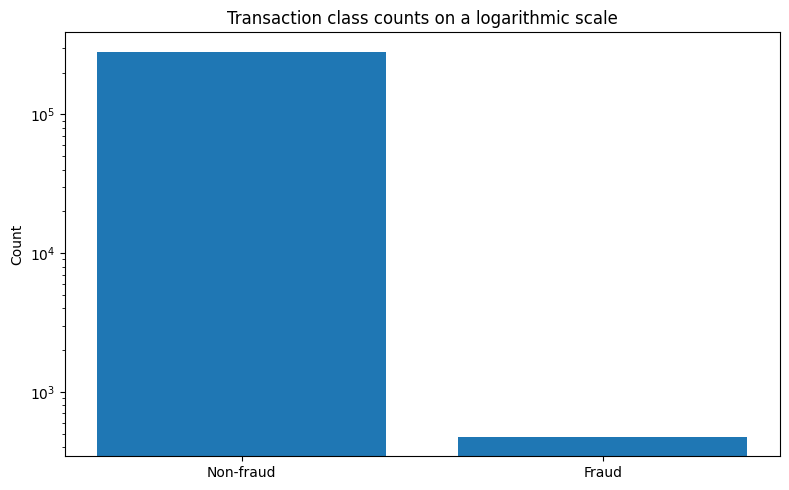

Saved: /kaggle/working/figures/01_class_counts.png


In [6]:
# Summarise the severe class imbalance and the numerical properties
# of the transaction dataset.

plt.figure(figsize=(8, 5))
plt.bar(class_summary["class"], class_summary["count"])
plt.yscale("log")
plt.title("Transaction class counts on a logarithmic scale")
plt.ylabel("Count")
save_show("01_class_counts")

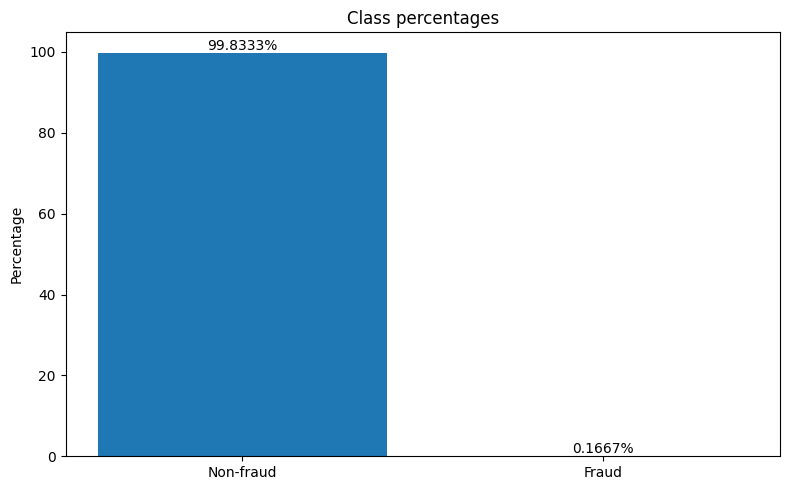

Saved: /kaggle/working/figures/02_class_percentages.png


In [7]:
# Summarise the severe class imbalance and the numerical properties
# of the transaction dataset.

plt.figure(figsize=(8, 5))
plt.bar(class_summary["class"], class_summary["percentage"])
plt.title("Class percentages")
plt.ylabel("Percentage")
for index, value in enumerate(class_summary["percentage"]):
    plt.text(index, value, f"{value:.4f}%", ha="center", va="bottom")
save_show("02_class_percentages")

## 6. Detailed exploratory data analysis

In [8]:
# Aggregate transactions to examine how fraud frequency changes
# across time periods or transaction-amount groups.

class_statistics = (
    df.groupby("Class")
      .agg(
          transactions=("Class", "size"),
          amount_mean=("Amount", "mean"),
          amount_median=("Amount", "median"),
          amount_std=("Amount", "std"),
          amount_max=("Amount", "max"),
          earliest_time=("Time", "min"),
          latest_time=("Time", "max")
      )
)
class_statistics.index = class_statistics.index.map({0: "Non-fraud", 1: "Fraud"})
display(class_statistics)

,transactions,amount_mean,amount_median,amount_std,amount_max,earliest_time,latest_time
Class,,,,,,,
Non-fraud,283253,88.41357,22.00000,250.37902,"25,691.16000",0.00000,"172,792.00000"
Fraud,473,123.87186,9.82000,260.21104,"2,125.87000",406.00000,"170,348.00000"


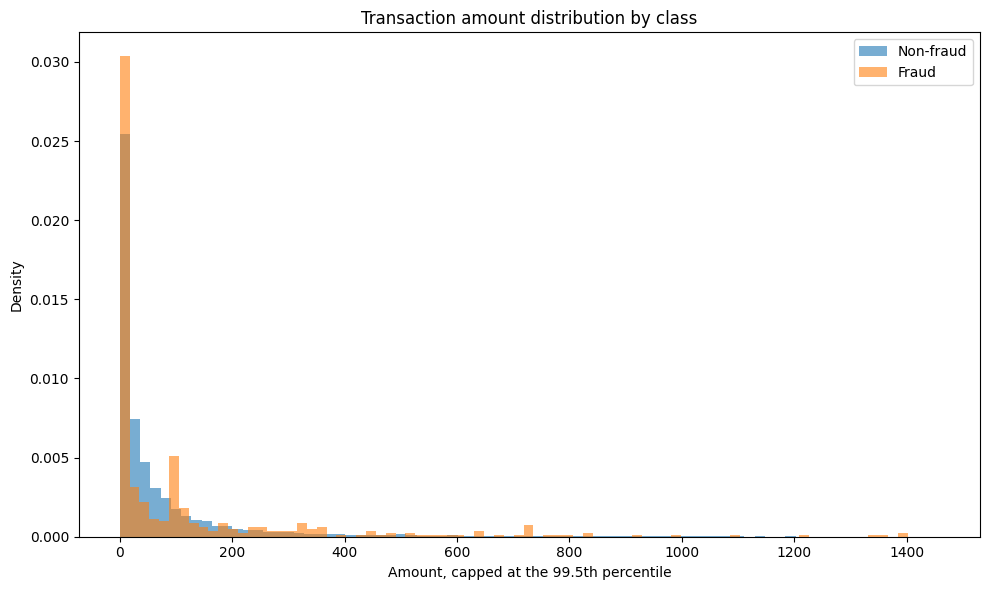

Saved: /kaggle/working/figures/03_amount_distribution.png


In [9]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

amount_limit = df["Amount"].quantile(0.995)

plt.figure(figsize=(10, 6))
plt.hist(
    df.loc[(df["Class"] == 0) & (df["Amount"] <= amount_limit), "Amount"],
    bins=80, density=True, alpha=0.6, label="Non-fraud"
)
plt.hist(
    df.loc[(df["Class"] == 1) & (df["Amount"] <= amount_limit), "Amount"],
    bins=80, density=True, alpha=0.6, label="Fraud"
)
plt.title("Transaction amount distribution by class")
plt.xlabel("Amount, capped at the 99.5th percentile")
plt.ylabel("Density")
plt.legend()
save_show("03_amount_distribution")

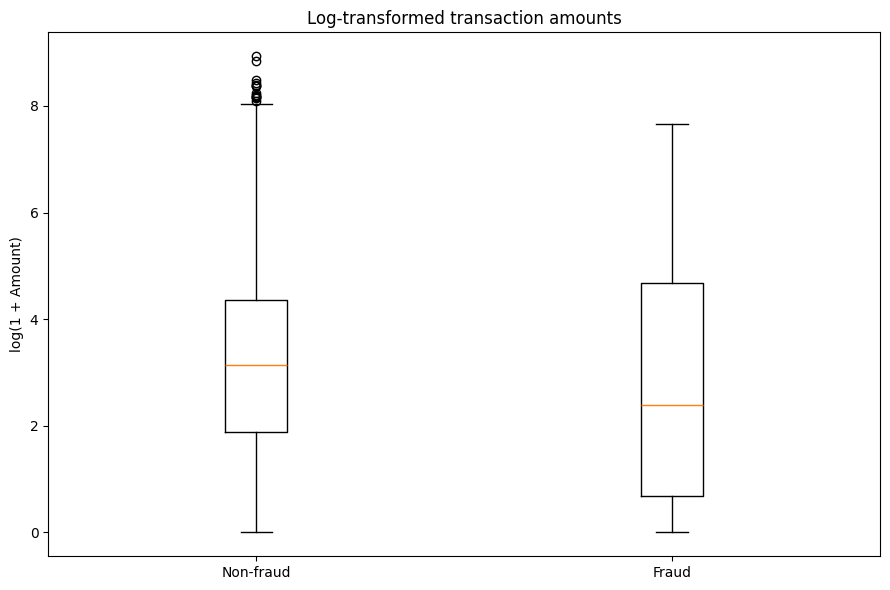

Saved: /kaggle/working/figures/04_amount_boxplot.png


In [10]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

normal_amount_sample = df.loc[df["Class"] == 0, "Amount"].sample(
    n=min(10000, int((df["Class"] == 0).sum())),
    random_state=SEED
)
fraud_amounts = df.loc[df["Class"] == 1, "Amount"]

plt.figure(figsize=(9, 6))
plt.boxplot(
    [np.log1p(normal_amount_sample), np.log1p(fraud_amounts)],
    labels=["Non-fraud", "Fraud"],
    showfliers=True
)
plt.title("Log-transformed transaction amounts")
plt.ylabel("log(1 + Amount)")
save_show("04_amount_boxplot")

,Hour,transactions,frauds,fraud_rate
0,0,7647,6,0.00078
1,1,4208,10,0.00238
2,2,3308,48,0.01451
3,3,3487,17,0.00488
4,4,2204,23,0.01044
5,5,2988,11,0.00368
6,6,4082,9,0.00220
7,7,7233,23,0.00318
8,8,10232,9,0.00088
9,9,15767,16,0.00101


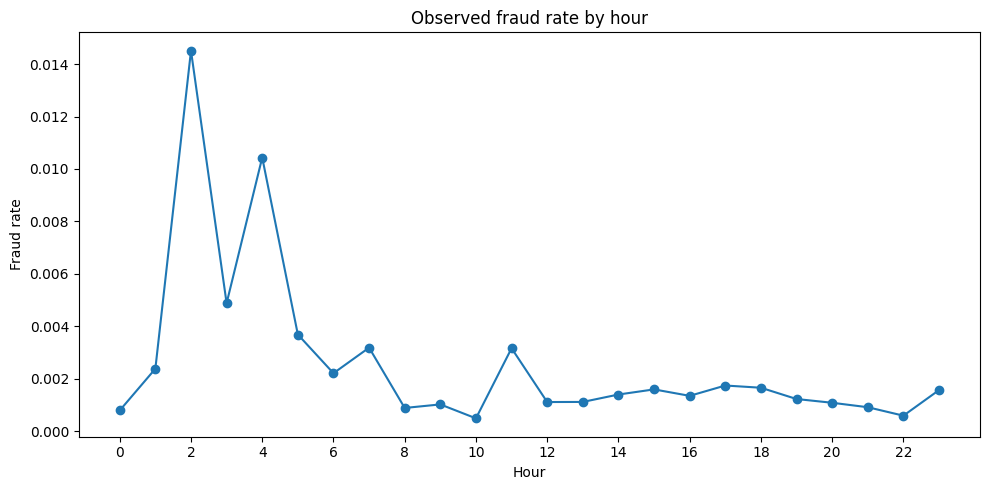

Saved: /kaggle/working/figures/05_hourly_fraud_rate.png


In [11]:
# Summarise the severe class imbalance and the numerical properties
# of the transaction dataset.

eda_df = df.copy()
eda_df["Hour"] = ((eda_df["Time"] / 3600) % 24).astype(int)

hourly = (
    eda_df.groupby("Hour")
          .agg(transactions=("Class", "size"), frauds=("Class", "sum"))
          .assign(fraud_rate=lambda frame: frame["frauds"] / frame["transactions"])
          .reset_index()
)
display(hourly)

plt.figure(figsize=(10, 5))
plt.plot(hourly["Hour"], hourly["fraud_rate"], marker="o")
plt.xticks(range(0, 24, 2))
plt.title("Observed fraud rate by hour")
plt.xlabel("Hour")
plt.ylabel("Fraud rate")
save_show("05_hourly_fraud_rate")

,AmountDecile,transactions,frauds,median_amount,fraud_rate
0,0,30331,171,0.99000,0.00564
1,1,26662,26,1.98000,0.00098
2,2,28222,36,5.70000,0.00128
3,3,28276,13,10.00000,0.00046
4,4,28484,14,16.99000,0.00049
5,5,28271,16,29.00000,0.00057
6,6,28521,23,46.95000,0.00081
7,7,28560,49,78.00000,0.00172
8,8,28027,43,140.79000,0.00153
9,9,28372,82,365.35000,0.00289


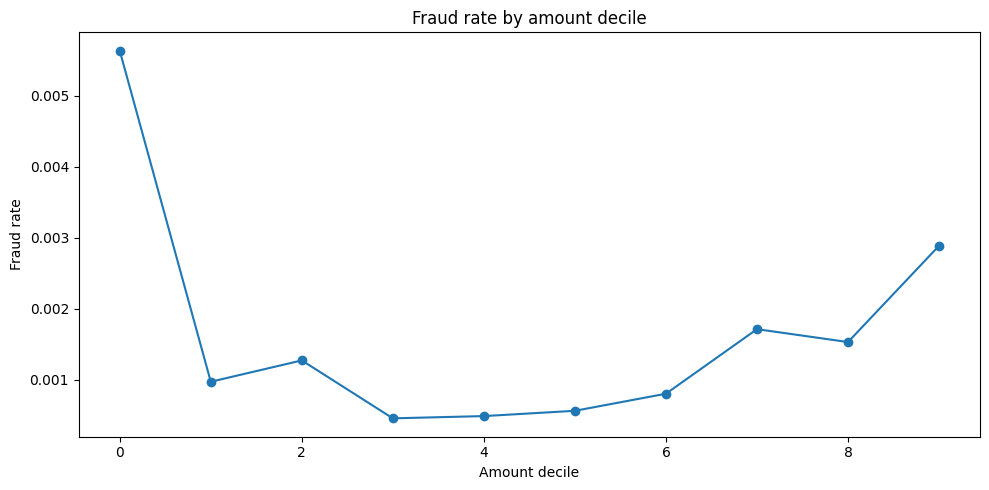

Saved: /kaggle/working/figures/06_amount_decile_fraud_rate.png


In [12]:
# Validate the dataset structure and data quality before analysis.
# This checks columns, missing values, class labels, and duplicate records.

eda_df["AmountDecile"] = pd.qcut(
    eda_df["Amount"], q=10, labels=False, duplicates="drop"
)

amount_deciles = (
    eda_df.groupby("AmountDecile")
          .agg(
              transactions=("Class", "size"),
              frauds=("Class", "sum"),
              median_amount=("Amount", "median")
          )
          .assign(fraud_rate=lambda frame: frame["frauds"] / frame["transactions"])
          .reset_index()
)
display(amount_deciles)

plt.figure(figsize=(10, 5))
plt.plot(amount_deciles["AmountDecile"], amount_deciles["fraud_rate"], marker="o")
plt.title("Fraud rate by amount decile")
plt.xlabel("Amount decile")
plt.ylabel("Fraud rate")
save_show("06_amount_decile_fraud_rate")

### Correlations using a balanced diagnostic sample

This sample is used only to make minority-class relationships visible in EDA. It is not used as the final test set.

In [13]:
# Use a balanced diagnostic sample to make fraud-related feature
# relationships easier to observe during EDA only.

fraud_rows = df[df["Class"] == 1]
nonfraud_sample = df[df["Class"] == 0].sample(
    n=len(fraud_rows), random_state=SEED
)
balanced_eda = pd.concat(
    [fraud_rows, nonfraud_sample],
    ignore_index=True
).sample(frac=1, random_state=SEED)

balanced_corr = (
    balanced_eda.corr(numeric_only=True)["Class"]
                .drop("Class")
                .sort_values(key=np.abs, ascending=False)
)

display(balanced_corr.head(15).to_frame("correlation_with_class"))

,correlation_with_class
V14,-0.74486
V4,0.69669
V11,0.68964
V12,-0.67806
V10,-0.62905
V16,-0.58473
V3,-0.55768
V9,-0.55250
V17,-0.54715
V2,0.47347


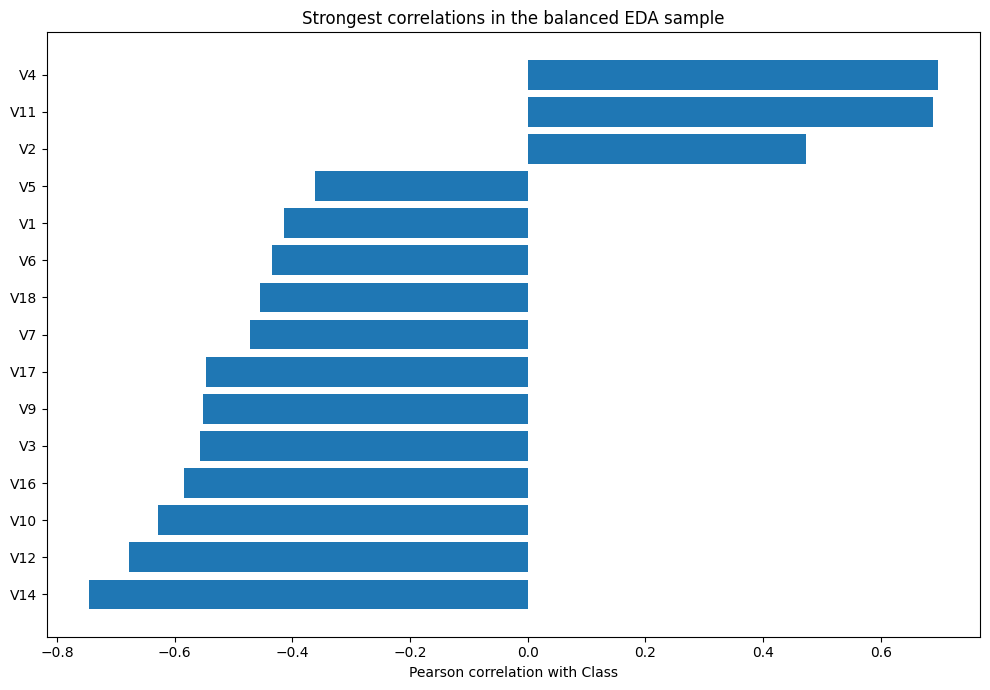

Saved: /kaggle/working/figures/07_balanced_correlations.png


In [14]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

top_corr = balanced_corr.head(15).sort_values()

plt.figure(figsize=(10, 7))
plt.barh(top_corr.index, top_corr.values)
plt.title("Strongest correlations in the balanced EDA sample")
plt.xlabel("Pearson correlation with Class")
save_show("07_balanced_correlations")

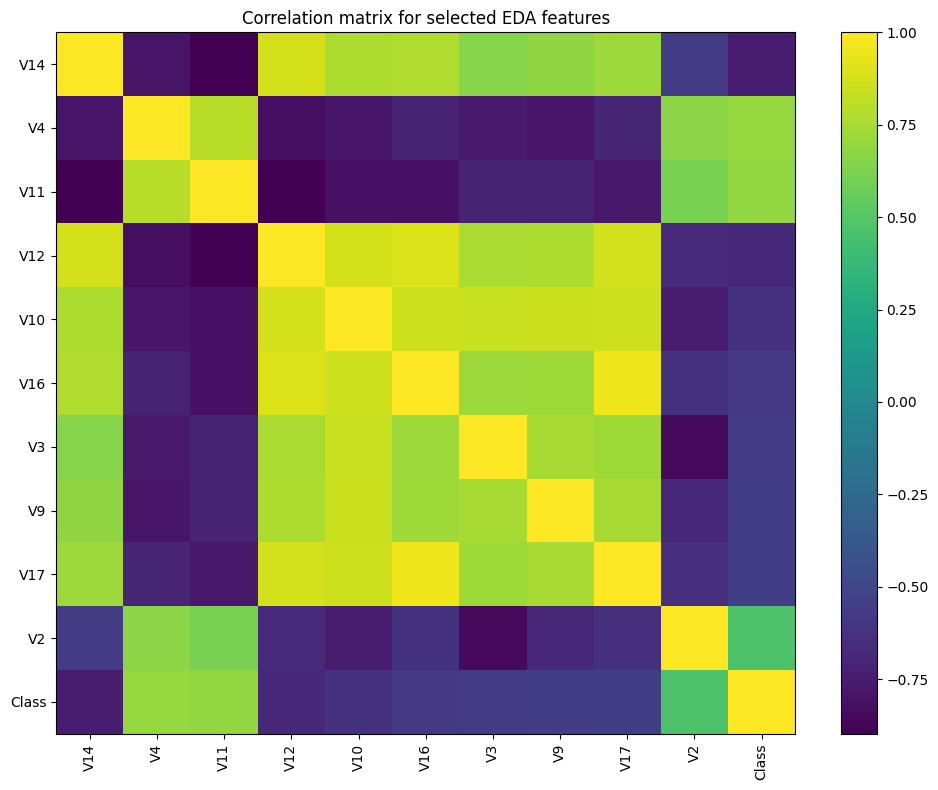

Saved: /kaggle/working/figures/08_correlation_matrix.png


In [15]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

corr_features = balanced_corr.head(10).index.tolist()
matrix = balanced_eda[corr_features + ["Class"]].corr()

plt.figure(figsize=(10, 8))
image = plt.imshow(matrix.values, aspect="auto")
plt.colorbar(image)
plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=90)
plt.yticks(range(len(matrix.index)), matrix.index)
plt.title("Correlation matrix for selected EDA features")
save_show("08_correlation_matrix")

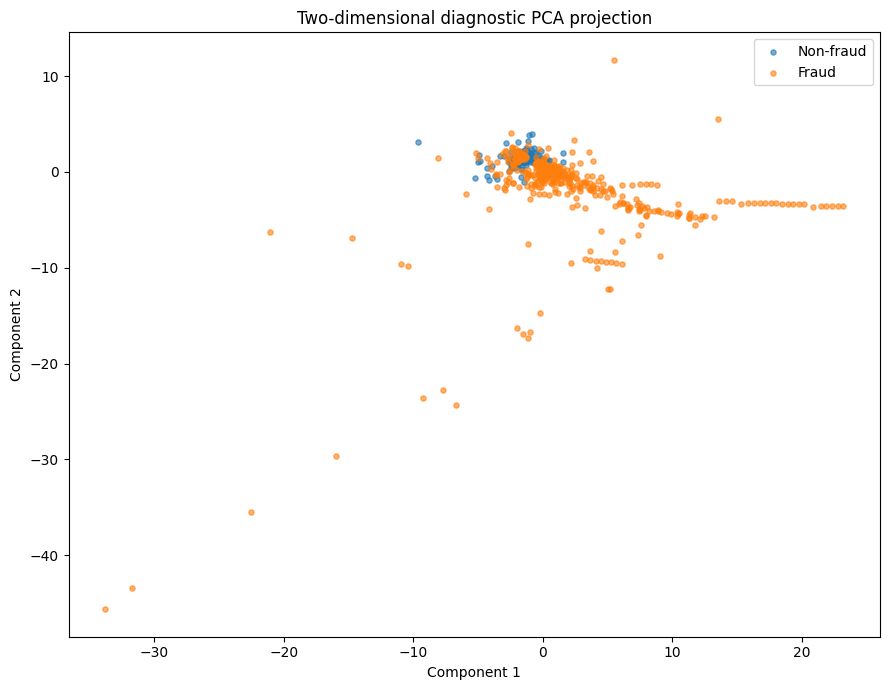

Saved: /kaggle/working/figures/09_pca_projection.png


In [16]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

projection_sample = balanced_eda.sample(
    n=min(4000, len(balanced_eda)),
    random_state=SEED
)
projection_X = projection_sample.drop(columns=["Class"])
projection_scaled = RobustScaler().fit_transform(projection_X)
projection = PCA(n_components=2, random_state=SEED).fit_transform(projection_scaled)

plt.figure(figsize=(9, 7))
for label, name in [(0, "Non-fraud"), (1, "Fraud")]:
    mask = projection_sample["Class"].to_numpy() == label
    plt.scatter(projection[mask, 0], projection[mask, 1], s=14, alpha=0.6, label=name)

plt.title("Two-dimensional diagnostic PCA projection")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
save_show("09_pca_projection")

## 7. Leakage-safe train, validation, and test split

- Training: model fitting and resampling.
- Validation: model selection and threshold tuning.
- Test: final evaluation only.

In [17]:
# Summarise the severe class imbalance and the numerical properties
# of the transaction dataset.

X = df.drop(columns=["Class"])
y = df["Class"].astype(int)

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size=0.25,
    stratify=y_train_valid,
    random_state=SEED
)

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "rows": [len(X_train), len(X_valid), len(X_test)],
    "fraud_cases": [int(y_train.sum()), int(y_valid.sum()), int(y_test.sum())],
    "fraud_rate": [y_train.mean(), y_valid.mean(), y_test.mean()]
})
display(split_summary)

assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)

,split,rows,fraud_cases,fraud_rate
0,Train,170235,284,0.00167
1,Validation,56745,94,0.00166
2,Test,56746,95,0.00167


## 8. Evaluation and threshold-selection utilities

In [18]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

def positive_scores(model, features: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(features)
        return probability[:, 1] if probability.ndim == 2 else probability

    if hasattr(model, "decision_function"):
        decision = model.decision_function(features)
        return 1 / (1 + np.exp(-decision))

    raise AttributeError("Model requires predict_proba or decision_function.")


def calculate_metrics(y_true, scores, threshold=0.50) -> Dict[str, float]:
    predictions = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if tn + fp else np.nan
    false_positive_rate = fp / (fp + tn) if fp + tn else np.nan
    false_negative_rate = fn / (fn + tp) if fn + tp else np.nan

    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, predictions, zero_division=0),
        "f2": fbeta_score(y_true, predictions, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "average_precision_auprc": average_precision_score(y_true, scores),
        "mcc": matthews_corrcoef(y_true, predictions),
        "brier_score": brier_score_loss(y_true, scores),
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
    }


def choose_f2_threshold(y_true, scores) -> Tuple[float, pd.DataFrame]:
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1]
    })

    denominator = 4 * table["precision"] + table["recall"]
    table["f2"] = np.where(
        denominator > 0,
        5 * table["precision"] * table["recall"] / denominator,
        0
    )

    best = table.loc[table["f2"].idxmax()]
    return float(best["threshold"]), table


def plot_confusion(y_true, scores, threshold, title, filename):
    predictions = (scores >= threshold).astype(int)
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])

    plt.figure(figsize=(6, 5))
    image = plt.imshow(matrix)
    plt.colorbar(image)
    plt.xticks([0, 1], ["Predicted non-fraud", "Predicted fraud"], rotation=20)
    plt.yticks([0, 1], ["Actual non-fraud", "Actual fraud"])

    for row in range(2):
        for column in range(2):
            plt.text(column, row, f"{matrix[row, column]:,}", ha="center", va="center")

    plt.title(title)
    plt.xlabel("Predicted class")
    plt.ylabel("Actual class")
    save_show(filename)

## 9. Baseline and ensemble models

The proposal’s intended approaches are represented through:

- class weighting;
- Random Forest bagging;
- Balanced Random Forest;
- EasyEnsemble;
- XGBoost boosting;
- SMOTE inside a pipeline;
- optional SMOTEENN;
- optional Stacking.

In [19]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
imbalance_weight = negative_count / positive_count

tree_count = 220 if FAST_MODE else 500
boost_count = 300 if FAST_MODE else 700

models: Dict[str, Any] = {
    "Dummy prior": DummyClassifier(strategy="prior"),

    "Logistic weighted": SkPipeline([
        ("scaler", RobustScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=3000,
            solver="liblinear",
            random_state=SEED
        ))
    ]),

    "Random Forest balanced": RandomForestClassifier(
        n_estimators=tree_count,
        max_depth=14,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED
    ),

    "Balanced Random Forest": BalancedRandomForestClassifier(
        n_estimators=tree_count,
        max_depth=14,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=SEED
    ),

    "Easy Ensemble": EasyEnsembleClassifier(
        n_estimators=8 if FAST_MODE else 16,
        n_jobs=-1,
        random_state=SEED
    ),

    "SMOTE + Logistic": ImbPipeline([
        ("scaler", RobustScaler()),
        ("smote", SMOTE(
            sampling_strategy=0.20 if FAST_MODE else 0.50,
            random_state=SEED
        )),
        ("model", LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=SEED
        ))
    ]),

    "XGBoost weighted": XGBClassifier(
        n_estimators=boost_count,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=2,
        reg_alpha=0.05,
        reg_lambda=1.0,
        scale_pos_weight=imbalance_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED
    )
}

if not FAST_MODE:
    models["SMOTEENN + Logistic"] = ImbPipeline([
        ("scaler", RobustScaler()),
        ("sampler", SMOTEENN(random_state=SEED)),
        ("model", LogisticRegression(
            max_iter=3000,
            solver="liblinear",
            random_state=SEED
        ))
    ])

if RUN_STACKING:
    models["Stacking ensemble"] = StackingClassifier(
        estimators=[
            ("lr", clone(models["Logistic weighted"])),
            ("rf", clone(models["Random Forest balanced"])),
            ("xgb", clone(models["XGBoost weighted"]))
        ],
        final_estimator=LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=SEED
        ),
        stack_method="predict_proba",
        cv=3,
        n_jobs=-1
    )

for name in models:
    print("-", name)

- Dummy prior
- Logistic weighted
- Random Forest balanced
- Balanced Random Forest
- Easy Ensemble
- SMOTE + Logistic
- XGBoost weighted


## 10. Train and compare models on validation data

In [20]:
# Create stratified training, validation, and untouched test sets.
# Splitting first prevents information leakage into final evaluation.

fitted_models = {}
validation_probabilities = {}
rows = []

for name, specification in models.items():
    print("\n" + "=" * 85)
    print("Training:", name)

    start = time.perf_counter()
    fitted = clone(specification)
    # Fit the cloned model on the training subset only.
    fitted.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    # Obtain fraud probabilities for validation-based comparison.
    scores = positive_scores(fitted, X_valid)
    metrics = calculate_metrics(y_valid, scores, threshold=0.50)
    metrics["model"] = name
    metrics["fit_seconds"] = elapsed

    fitted_models[name] = fitted
    validation_probabilities[name] = scores
    rows.append(metrics)

    print(
        f"AUPRC={metrics['average_precision_auprc']:.4f} | "
        f"ROC-AUC={metrics['roc_auc']:.4f} | "
        f"Precision={metrics['precision']:.4f} | "
        f"Recall={metrics['recall']:.4f} | "
        f"Time={elapsed:.1f}s"
    )

validation_results = (
    pd.DataFrame(rows)
      .set_index("model")
      .sort_values("average_precision_auprc", ascending=False)
)

display(validation_results[[
    "average_precision_auprc", "roc_auc", "precision", "recall",
    "f1", "f2", "balanced_accuracy", "mcc", "brier_score", "fit_seconds"
]])


Training: Dummy prior
AUPRC=0.0017 | ROC-AUC=0.5000 | Precision=0.0000 | Recall=0.0000 | Time=0.0s

Training: Logistic weighted
AUPRC=0.7868 | ROC-AUC=0.9790 | Precision=0.0539 | Recall=0.9043 | Time=4.9s

Training: Random Forest balanced
AUPRC=0.8637 | ROC-AUC=0.9527 | Precision=0.8977 | Recall=0.8404 | Time=99.5s

Training: Balanced Random Forest
AUPRC=0.7595 | ROC-AUC=0.9702 | Precision=0.1148 | Recall=0.8936 | Time=5.7s

Training: Easy Ensemble
AUPRC=0.7632 | ROC-AUC=0.9779 | Precision=0.0453 | Recall=0.9043 | Time=4.0s

Training: SMOTE + Logistic
AUPRC=0.8020 | ROC-AUC=0.9765 | Precision=0.2276 | Recall=0.8936 | Time=3.5s

Training: XGBoost weighted
AUPRC=0.8847 | ROC-AUC=0.9720 | Precision=0.8710 | Recall=0.8617 | Time=4.4s


,average_precision_auprc,roc_auc,precision,recall,f1,f2,balanced_accuracy,mcc,brier_score,fit_seconds
model,,,,,,,,,,
XGBoost weighted,0.88469,0.97197,0.87097,0.86170,0.86631,0.86354,0.93075,0.86610,0.00042,4.39633
Random Forest balanced,0.86369,0.95270,0.89773,0.84043,0.86813,0.85129,0.92013,0.86839,0.00043,99.45855
SMOTE + Logistic,0.80201,0.97653,0.22764,0.89362,0.36285,0.56376,0.94429,0.44958,0.00505,3.53981
Logistic weighted,0.78683,0.97898,0.05387,0.90426,0.10167,0.21750,0.93895,0.21713,0.02295,4.86998
Easy Ensemble,0.76315,0.97786,0.04533,0.90426,0.08634,0.18880,0.93633,0.19854,0.14599,3.95057
Balanced Random Forest,0.75946,0.97022,0.11475,0.89362,0.20339,0.37906,0.94109,0.31792,0.01877,5.65695
Dummy prior,0.00166,0.50000,0.00000,0.00000,0.00000,0.00000,0.50000,0.00000,0.00165,0.01721


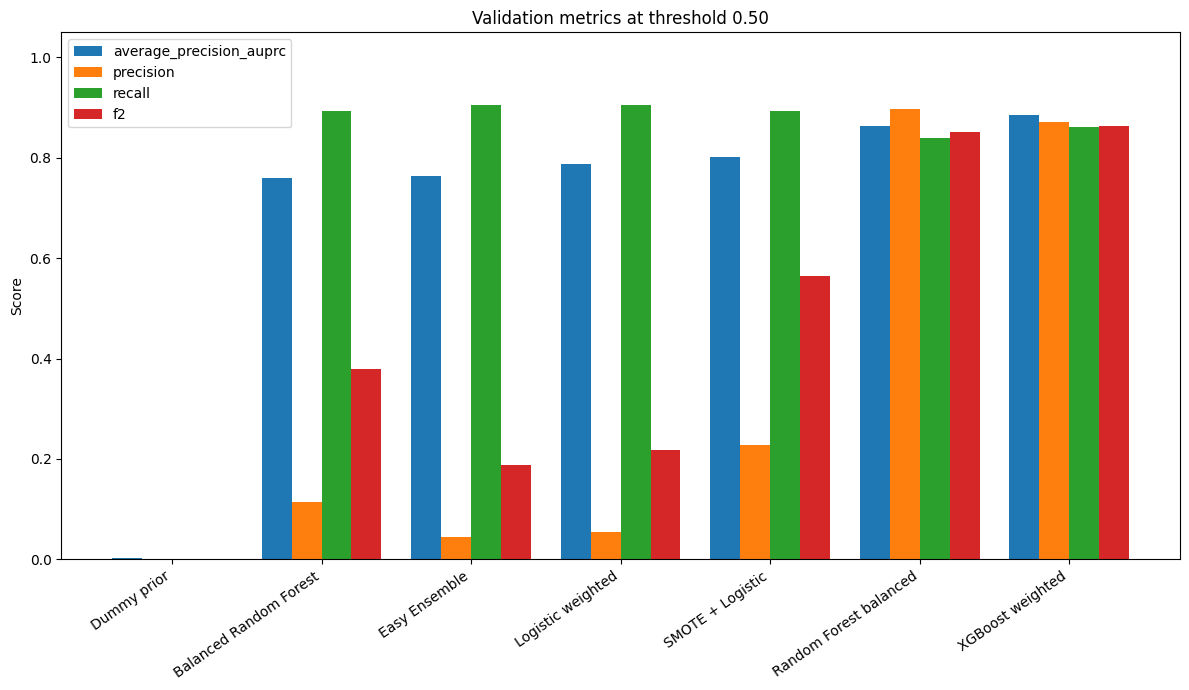

Saved: /kaggle/working/figures/10_model_metric_comparison.png


In [21]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

plot_data = validation_results[
    ["average_precision_auprc", "precision", "recall", "f2"]
].sort_values("average_precision_auprc")

x = np.arange(len(plot_data))
width = 0.20

plt.figure(figsize=(12, 7))
for index, metric in enumerate(plot_data.columns):
    plt.bar(
        x + (index - 1.5) * width,
        plot_data[metric],
        width=width,
        label=metric
    )

plt.xticks(x, plot_data.index, rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.title("Validation metrics at threshold 0.50")
plt.ylabel("Score")
plt.legend()
save_show("10_model_metric_comparison")

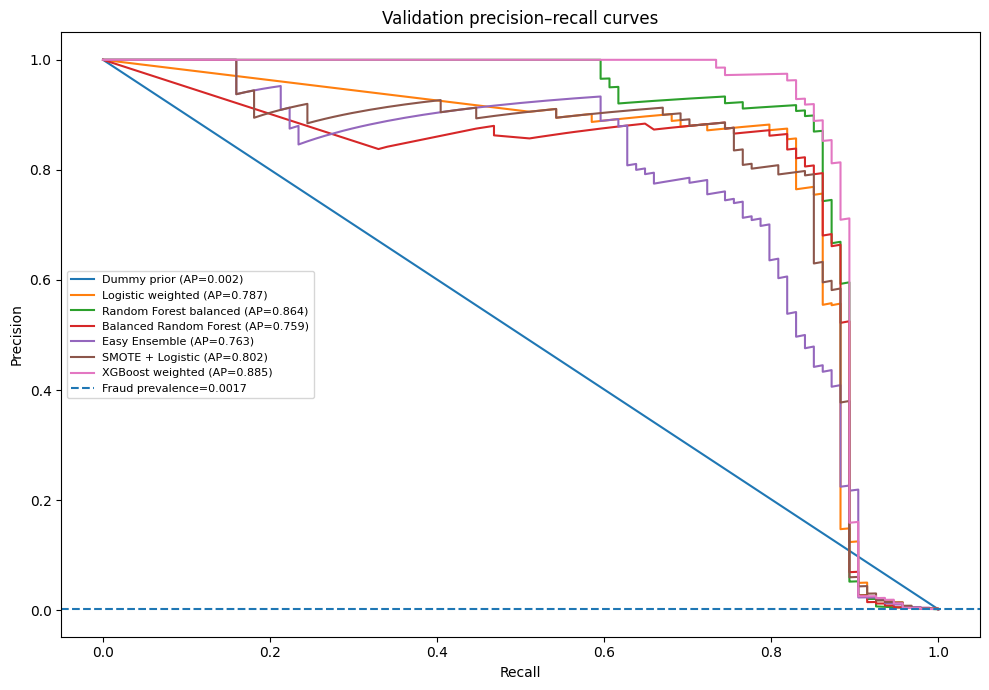

Saved: /kaggle/working/figures/11_precision_recall_curves.png


In [22]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

plt.figure(figsize=(10, 7))
for name, scores in validation_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_valid, scores)
    ap = average_precision_score(y_valid, scores)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.axhline(y_valid.mean(), linestyle="--", label=f"Fraud prevalence={y_valid.mean():.4f}")
plt.title("Validation precision–recall curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(fontsize=8)
save_show("11_precision_recall_curves")

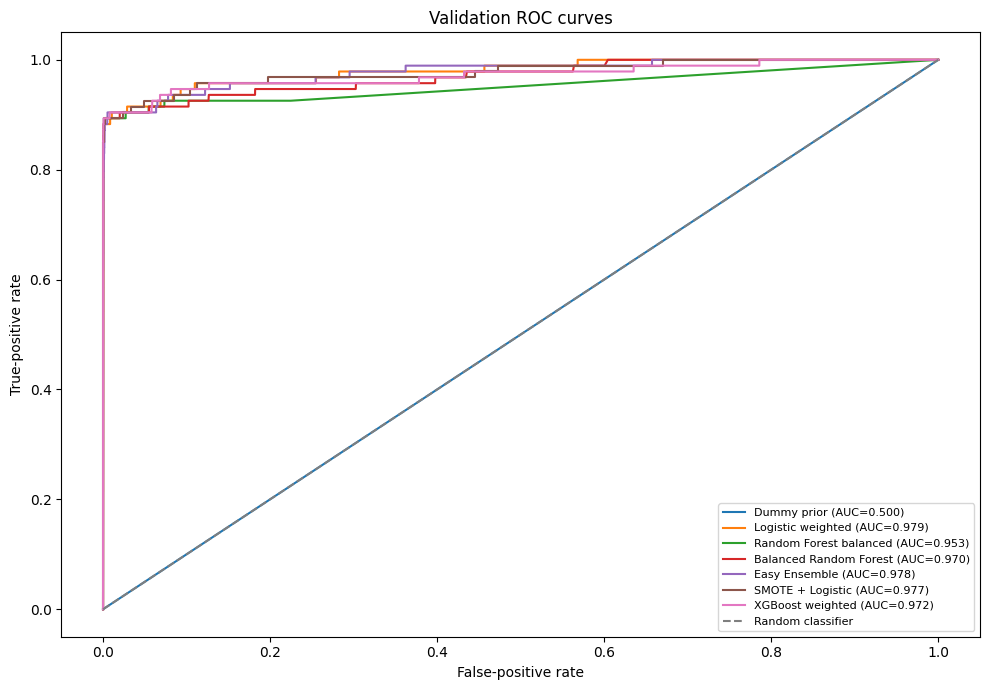

Saved: /kaggle/working/figures/12_roc_curves.png


In [23]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

plt.figure(figsize=(10, 7))
for name, scores in validation_probabilities.items():
    fpr, tpr, _ = roc_curve(y_valid, scores)
    auc_value = roc_auc_score(y_valid, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Validation ROC curves")
plt.xlabel("False-positive rate")
plt.ylabel("True-positive rate")
plt.legend(fontsize=8)
save_show("12_roc_curves")

## 11. Select the best model by validation AUPRC and optimise F2 threshold

In [24]:
# Train each candidate model on the training set and compare it on
# validation data using AUPRC and other imbalance-aware metrics.

best_model_name = validation_results.index[0]
best_model = fitted_models[best_model_name]
best_valid_scores = validation_probabilities[best_model_name]

best_threshold, threshold_table = choose_f2_threshold(y_valid, best_valid_scores)

print("Selected model:", best_model_name)
print(f"Selected F2 threshold: {best_threshold:.8f}")

selected_row = threshold_table.loc[
    (threshold_table["threshold"] - best_threshold).abs().idxmin()
]
display(selected_row.to_frame("value"))

Selected model: XGBoost weighted
Selected F2 threshold: 0.33606732


,value
threshold,0.33607
precision,0.85417
recall,0.87234
f2,0.86864


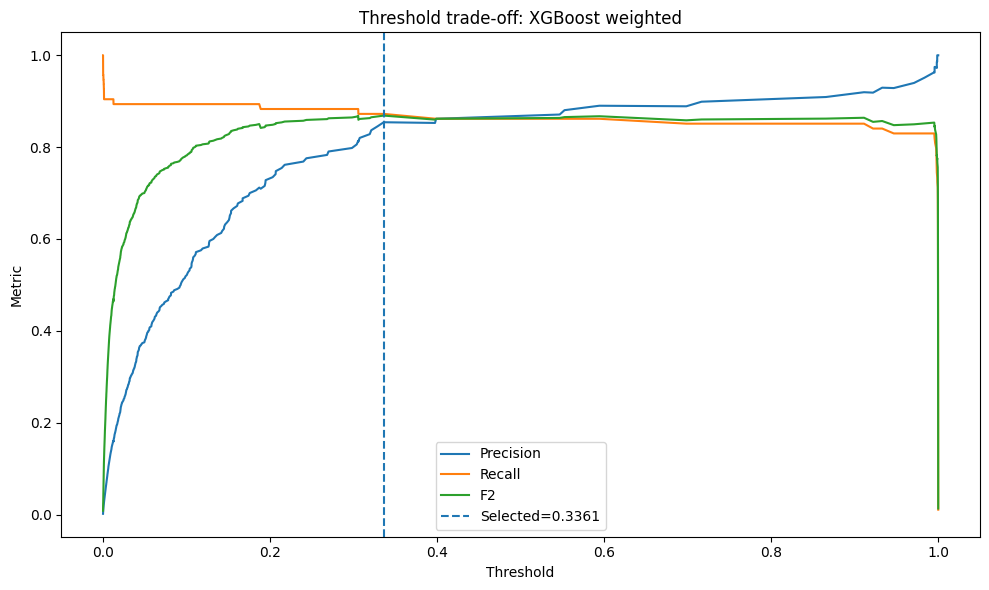

Saved: /kaggle/working/figures/13_threshold_tradeoff.png


In [25]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

plt.figure(figsize=(10, 6))
plt.plot(threshold_table["threshold"], threshold_table["precision"], label="Precision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], label="Recall")
plt.plot(threshold_table["threshold"], threshold_table["f2"], label="F2")
plt.axvline(best_threshold, linestyle="--", label=f"Selected={best_threshold:.4f}")
plt.title(f"Threshold trade-off: {best_model_name}")
plt.xlabel("Threshold")
plt.ylabel("Metric")
plt.legend()
save_show("13_threshold_tradeoff")

## 12. Final untouched test evaluation

In [26]:
# Create stratified training, validation, and untouched test sets.
# Splitting first prevents information leakage into final evaluation.

test_scores = positive_scores(best_model, X_test)

test_default = calculate_metrics(y_test, test_scores, threshold=0.50)
test_tuned = calculate_metrics(y_test, test_scores, threshold=best_threshold)

test_comparison = pd.DataFrame(
    [test_default, test_tuned],
    index=["Threshold 0.50", f"Validation threshold {best_threshold:.8f}"]
)

display(test_comparison[[
    "threshold", "average_precision_auprc", "roc_auc", "precision",
    "recall", "specificity", "f1", "f2", "balanced_accuracy",
    "mcc", "brier_score", "tn", "fp", "fn", "tp"
]])

test_predictions = (test_scores >= best_threshold).astype(int)

print(classification_report(
    y_test,
    test_predictions,
    target_names=["Non-fraud", "Fraud"],
    digits=4,
    zero_division=0
))

,threshold,average_precision_auprc,roc_auc,precision,recall,specificity,f1,f2,balanced_accuracy,mcc,brier_score,tn,fp,fn,tp
Threshold 0.50,0.50000,0.81953,0.97342,0.88372,0.80000,0.99982,0.83978,0.81545,0.89991,0.84057,0.00048,56641,10,19,76
Validation threshold 0.33606732,0.33607,0.81953,0.97342,0.79167,0.80000,0.99965,0.79581,0.79832,0.89982,0.79548,0.00048,56631,20,19,76


              precision    recall  f1-score   support

   Non-fraud     0.9997    0.9996    0.9997     56651
       Fraud     0.7917    0.8000    0.7958        95

    accuracy                         0.9993     56746
   macro avg     0.8957    0.8998    0.8977     56746
weighted avg     0.9993    0.9993    0.9993     56746



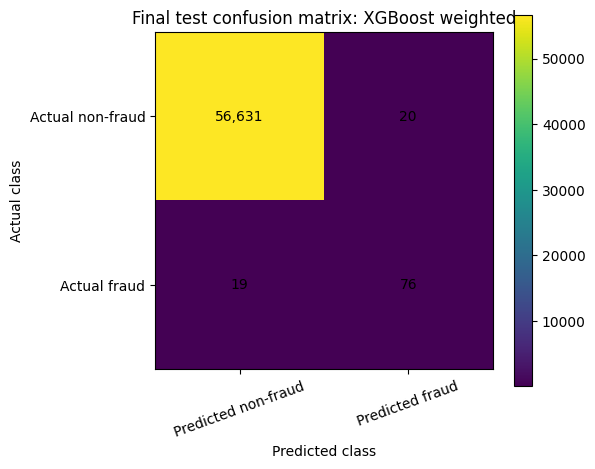

Saved: /kaggle/working/figures/14_test_confusion.png


In [27]:
# Select the strongest validation model using AUPRC, then choose
# a decision threshold on validation data by maximising F2.

plot_confusion(
    y_test, test_scores, best_threshold,
    title=f"Final test confusion matrix: {best_model_name}",
    filename="14_test_confusion"
)

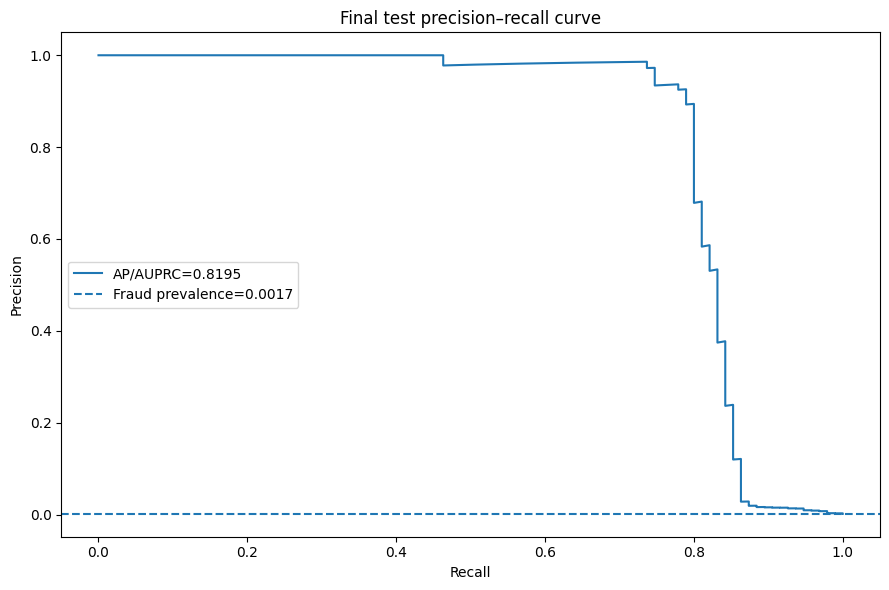

Saved: /kaggle/working/figures/15_test_precision_recall.png


In [28]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

test_precision, test_recall, _ = precision_recall_curve(y_test, test_scores)
test_ap = average_precision_score(y_test, test_scores)

plt.figure(figsize=(9, 6))
plt.plot(test_recall, test_precision, label=f"AP/AUPRC={test_ap:.4f}")
plt.axhline(y_test.mean(), linestyle="--", label=f"Fraud prevalence={y_test.mean():.4f}")
plt.title("Final test precision–recall curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
save_show("15_test_precision_recall")

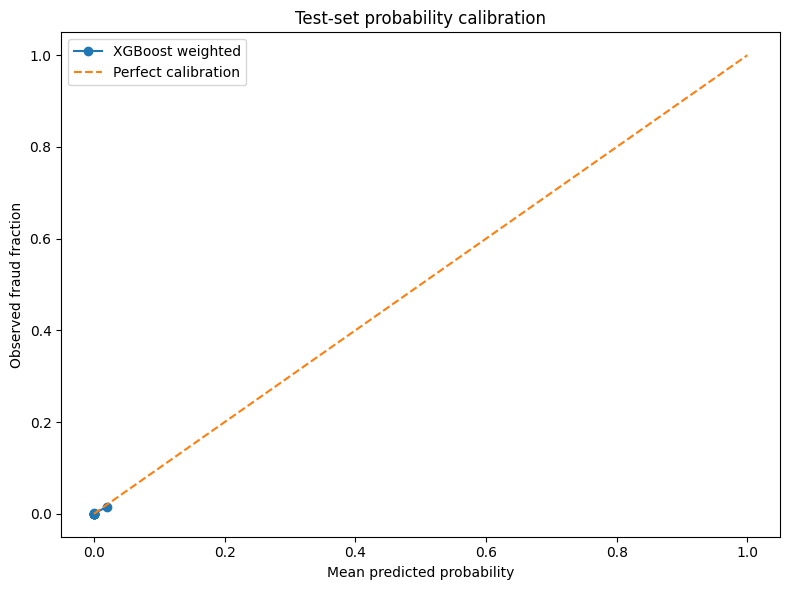

Saved: /kaggle/working/figures/16_calibration.png


In [29]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

fraction_positive, mean_prediction = calibration_curve(
    y_test, test_scores,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(8, 6))
plt.plot(mean_prediction, fraction_positive, marker="o", label=best_model_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.title("Test-set probability calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraud fraction")
plt.legend()
save_show("16_calibration")

## 13. Cross-validation on training plus validation data

In [30]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_CROSS_VALIDATION:
    cv_X = pd.concat([X_train, X_valid])
    cv_y = pd.concat([y_train, y_valid])

    folds = 3 if FAST_MODE else 5
    splitter = StratifiedKFold(n_splits=folds, shuffle=True, random_state=SEED)

    scoring = {
        "average_precision": "average_precision",
        "roc_auc": "roc_auc",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "balanced_accuracy": "balanced_accuracy"
    }

    cv_output = cross_validate(
        clone(models[best_model_name]),
        cv_X,
        cv_y,
        cv=splitter,
        scoring=scoring,
        n_jobs=-1
    )

    cv_table = pd.DataFrame({
        key.replace("test_", ""): value
        for key, value in cv_output.items()
        if key.startswith("test_")
    })

    display(cv_table)
    display(cv_table.agg(["mean", "std"]).T)
else:
    print("Cross-validation disabled.")

,average_precision,roc_auc,precision,recall,f1,balanced_accuracy
0,0.82935,0.97865,0.86441,0.80952,0.83607,0.90466
1,0.86620,0.98319,0.84496,0.86508,0.85490,0.93241
2,0.87787,0.98128,0.87805,0.85714,0.86747,0.92847


,mean,std
average_precision,0.85781,0.02533
roc_auc,0.98104,0.00228
precision,0.86247,0.01663
recall,0.84392,0.03005
f1,0.85281,0.01581
balanced_accuracy,0.92185,0.01502


## 14. Optional XGBoost hyperparameter tuning

In [31]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_TUNING:
    search_model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=imbalance_weight,
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED
    )

    search_space = {
        "n_estimators": [200, 350, 500, 700],
        "max_depth": [3, 4, 5, 6, 8],
        "learning_rate": [0.02, 0.04, 0.06, 0.10],
        "subsample": [0.70, 0.85, 1.00],
        "colsample_bytree": [0.70, 0.85, 1.00],
        "min_child_weight": [1, 2, 5, 10],
        "reg_alpha": [0.0, 0.05, 0.2],
        "reg_lambda": [0.5, 1.0, 2.0]
    }

    search = RandomizedSearchCV(
        search_model,
        param_distributions=search_space,
        n_iter=12 if FAST_MODE else 30,
        scoring="average_precision",
        cv=3,
        n_jobs=-1,
        random_state=SEED,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train)
    print("Best cross-validated AUPRC:", search.best_score_)
    print(json.dumps(search.best_params_, indent=2))

    tuned_valid_scores = positive_scores(search.best_estimator_, X_valid)
    display(pd.Series(
        calculate_metrics(y_valid, tuned_valid_scores),
        name="Tuned XGBoost validation metrics"
    ))
else:
    print("Set RUN_TUNING=True to run optional tuning.")

Set RUN_TUNING=True to run optional tuning.


## 15. Model-agnostic explainability on real anonymised data

Permutation importance measures the decrease in validation AUPRC after each feature is shuffled. The result identifies influential PCA components, but their original semantic meaning remains unavailable.

In [32]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

importance_size = min(12000 if FAST_MODE else 30000, len(X_valid))
importance_indices = X_valid.sample(n=importance_size, random_state=SEED).index

X_importance = X_valid.loc[importance_indices]
y_importance = y_valid.loc[importance_indices]

permutation = permutation_importance(
    best_model,
    X_importance,
    y_importance,
    scoring="average_precision",
    n_repeats=3 if FAST_MODE else 7,
    random_state=SEED,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_importance.columns,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(15))

,feature,importance_mean,importance_std
14,V14,0.11195,0.07632
4,V4,0.03188,0.02106
11,V11,0.00380,0.00538
3,V3,0.00000,0.00000
8,V8,0.00000,0.00000
12,V12,0.00000,0.00000
23,V23,0.00000,0.00000
20,V20,0.00000,0.00000
18,V18,0.00000,0.00000
1,V1,0.00000,0.00000


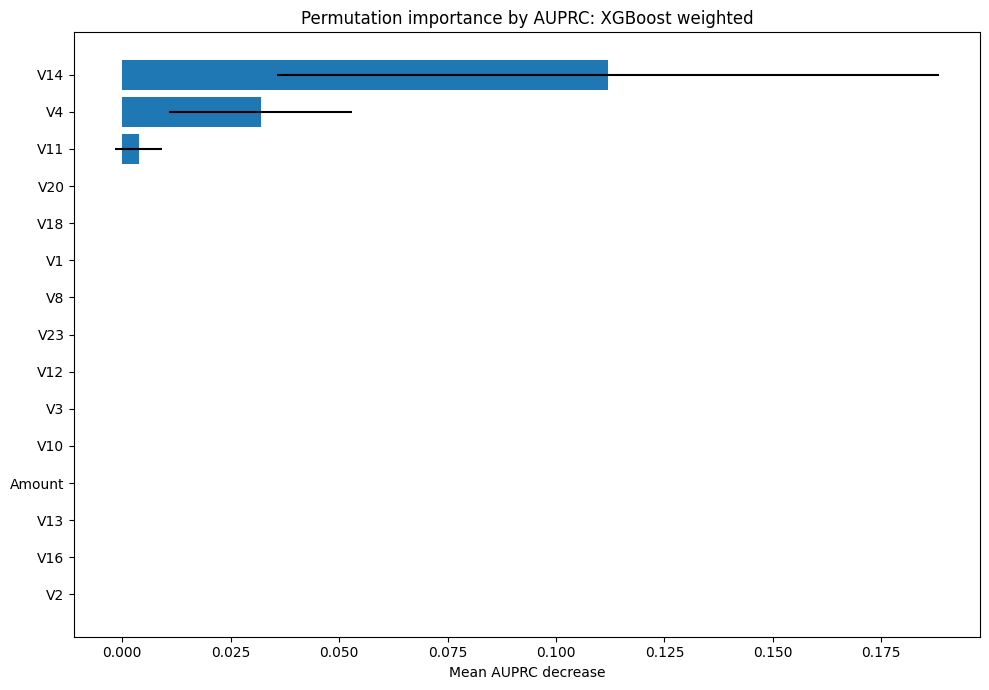

Saved: /kaggle/working/figures/17_permutation_importance.png


In [33]:
# Create and save an explanatory chart for the exploratory analysis
# or model-evaluation stage.

importance_plot = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(
    importance_plot["feature"],
    importance_plot["importance_mean"],
    xerr=importance_plot["importance_std"]
)
plt.title(f"Permutation importance by AUPRC: {best_model_name}")
plt.xlabel("Mean AUPRC decrease")
save_show("17_permutation_importance")

## 16. Optional synthetic transaction-data simulator

This original simplified simulator is inspired by the public handbook’s reproducible simulation approach. It generates non-real customers, terminals, legitimate transactions, and three fraud scenarios:

1. compromised terminals;
2. stolen-card behaviour;
3. abnormal transaction amounts.

The generated features are interpretable, supporting explainability analysis that is not possible with anonymous PCA components.

In [34]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

def simulate_transactions(
    n_customers=900,
    n_terminals=180,
    n_days=40,
    seed=SEED
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    start = pd.Timestamp("2026-07-01")

    customers = pd.DataFrame({
        "CUSTOMER_ID": np.arange(n_customers),
        "CUSTOMER_X": rng.uniform(0, 100, n_customers),
        "CUSTOMER_Y": rng.uniform(0, 100, n_customers),
        "MEAN_AMOUNT": rng.lognormal(3.1, 0.65, n_customers),
        "STD_AMOUNT": rng.uniform(5, 45, n_customers),
        "TX_PER_DAY": rng.gamma(1.8, 0.55, n_customers),
        "ACTIVE_HOUR": rng.integers(7, 22, n_customers)
    })

    terminals = pd.DataFrame({
        "TERMINAL_ID": np.arange(n_terminals),
        "TERMINAL_X": rng.uniform(0, 100, n_terminals),
        "TERMINAL_Y": rng.uniform(0, 100, n_terminals)
    })

    terminal_coordinates = terminals[["TERMINAL_X", "TERMINAL_Y"]].to_numpy()
    records = []

    for customer in customers.itertuples(index=False):
        transaction_count = rng.poisson(max(customer.TX_PER_DAY * n_days, 1))

        customer_xy = np.array([customer.CUSTOMER_X, customer.CUSTOMER_Y])
        distances = np.sqrt(((terminal_coordinates - customer_xy) ** 2).sum(axis=1))
        nearby_ids = np.argsort(distances)[:min(12, n_terminals)]
        weights = np.exp(-distances[nearby_ids] / 12)
        weights /= weights.sum()

        days = rng.integers(0, n_days, transaction_count)
        hours = np.mod(
            np.rint(rng.normal(customer.ACTIVE_HOUR, 3.0, transaction_count)),
            24
        ).astype(int)
        minutes = rng.integers(0, 60, transaction_count)
        seconds = rng.integers(0, 60, transaction_count)
        selected_terminals = rng.choice(
            nearby_ids, transaction_count, replace=True, p=weights
        )
        amounts = np.clip(
            rng.normal(customer.MEAN_AMOUNT, customer.STD_AMOUNT, transaction_count),
            0.50,
            None
        )

        for day, hour, minute, second, terminal_id, amount in zip(
            days, hours, minutes, seconds, selected_terminals, amounts
        ):
            records.append({
                "TX_DATETIME": (
                    start
                    + pd.Timedelta(days=int(day))
                    + pd.Timedelta(hours=int(hour))
                    + pd.Timedelta(minutes=int(minute))
                    + pd.Timedelta(seconds=int(second))
                ),
                "CUSTOMER_ID": int(customer.CUSTOMER_ID),
                "TERMINAL_ID": int(terminal_id),
                "TX_AMOUNT": float(round(amount, 2)),
                "CUSTOMER_X": float(customer.CUSTOMER_X),
                "CUSTOMER_Y": float(customer.CUSTOMER_Y),
                "CUSTOMER_MEAN_AMOUNT": float(customer.MEAN_AMOUNT),
                "CUSTOMER_STD_AMOUNT": float(customer.STD_AMOUNT)
            })

    transactions = pd.DataFrame(records).sort_values("TX_DATETIME").reset_index(drop=True)
    transactions = transactions.merge(terminals, on="TERMINAL_ID", how="left")
    transactions["TX_FRAUD"] = 0
    transactions["FRAUD_SCENARIO"] = "legitimate"

    day_number = (transactions["TX_DATETIME"] - start).dt.days

    compromised = rng.choice(
        terminals["TERMINAL_ID"],
        max(3, int(n_terminals * 0.025)),
        replace=False
    )
    compromised_mask = (
        transactions["TERMINAL_ID"].isin(compromised)
        & day_number.between(int(n_days * 0.35), int(n_days * 0.60))
        & (rng.random(len(transactions)) < 0.22)
    )
    transactions.loc[compromised_mask, "TX_FRAUD"] = 1
    transactions.loc[compromised_mask, "FRAUD_SCENARIO"] = "compromised_terminal"
    transactions.loc[compromised_mask, "TX_AMOUNT"] *= rng.uniform(
        1.5, 3.5, compromised_mask.sum()
    )

    stolen_customers = rng.choice(
        customers["CUSTOMER_ID"],
        max(5, int(n_customers * 0.018)),
        replace=False
    )
    stolen_mask = (
        transactions["CUSTOMER_ID"].isin(stolen_customers)
        & (rng.random(len(transactions)) < 0.28)
    )

    new_terminal_ids = rng.integers(0, n_terminals, stolen_mask.sum())
    terminal_lookup = terminals.set_index("TERMINAL_ID")

    transactions.loc[stolen_mask, "TERMINAL_ID"] = new_terminal_ids
    transactions.loc[stolen_mask, "TERMINAL_X"] = terminal_lookup.loc[
        new_terminal_ids, "TERMINAL_X"
    ].to_numpy()
    transactions.loc[stolen_mask, "TERMINAL_Y"] = terminal_lookup.loc[
        new_terminal_ids, "TERMINAL_Y"
    ].to_numpy()
    transactions.loc[stolen_mask, "TX_FRAUD"] = 1
    transactions.loc[stolen_mask, "FRAUD_SCENARIO"] = "stolen_card"
    transactions.loc[stolen_mask, "TX_AMOUNT"] *= rng.uniform(
        2.0, 5.0, stolen_mask.sum()
    )

    abnormal_mask = rng.random(len(transactions)) < 0.0025
    transactions.loc[abnormal_mask, "TX_FRAUD"] = 1
    transactions.loc[abnormal_mask, "FRAUD_SCENARIO"] = "abnormal_amount"
    transactions.loc[abnormal_mask, "TX_AMOUNT"] *= rng.uniform(
        4.0, 9.0, abnormal_mask.sum()
    )

    transactions["TX_HOUR"] = transactions["TX_DATETIME"].dt.hour
    transactions["TX_DAY_OF_WEEK"] = transactions["TX_DATETIME"].dt.dayofweek
    transactions["TX_DURING_NIGHT"] = transactions["TX_HOUR"].isin(range(0, 6)).astype(int)
    transactions["TX_DURING_WEEKEND"] = transactions["TX_DAY_OF_WEEK"].isin([5, 6]).astype(int)

    transactions["DISTANCE_TO_TERMINAL"] = np.sqrt(
        (transactions["CUSTOMER_X"] - transactions["TERMINAL_X"]) ** 2
        + (transactions["CUSTOMER_Y"] - transactions["TERMINAL_Y"]) ** 2
    )

    safe_std = transactions["CUSTOMER_STD_AMOUNT"].replace(0, 1)
    transactions["AMOUNT_ZSCORE"] = (
        transactions["TX_AMOUNT"] - transactions["CUSTOMER_MEAN_AMOUNT"]
    ) / safe_std
    transactions["AMOUNT_TO_MEAN_RATIO"] = (
        transactions["TX_AMOUNT"]
        / transactions["CUSTOMER_MEAN_AMOUNT"].clip(lower=0.01)
    )
    transactions["IS_DISTANT_TERMINAL"] = (
        transactions["DISTANCE_TO_TERMINAL"] > 30
    ).astype(int)
    transactions["TX_TIME_SECONDS"] = (
        transactions["TX_DATETIME"] - start
    ).dt.total_seconds()

    return transactions.sort_values("TX_DATETIME").reset_index(drop=True)

In [35]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_SIMULATOR:
    simulated_df = simulate_transactions(
        n_customers=900 if FAST_MODE else 2500,
        n_terminals=180 if FAST_MODE else 500,
        n_days=40 if FAST_MODE else 90
    )

    simulated_path = OUTPUT_DIR / "simulated_transactions.csv"
    simulated_df.to_csv(simulated_path, index=False)

    display(pd.DataFrame({
        "rows": [len(simulated_df)],
        "fraud_cases": [int(simulated_df["TX_FRAUD"].sum())],
        "fraud_rate": [simulated_df["TX_FRAUD"].mean()],
        "customers": [simulated_df["CUSTOMER_ID"].nunique()],
        "terminals": [simulated_df["TERMINAL_ID"].nunique()],
        "start": [simulated_df["TX_DATETIME"].min()],
        "end": [simulated_df["TX_DATETIME"].max()]
    }))

    display(simulated_df.head())
    display(simulated_df["FRAUD_SCENARIO"].value_counts().to_frame("count"))
    print("Saved:", simulated_path)
else:
    print("Simulator disabled.")

,rows,fraud_cases,fraud_rate,customers,terminals,start,end
0,35245,303,0.00860,898,180,2026-07-01 00:00:27,2026-08-09 23:49:52


,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,CUSTOMER_X,CUSTOMER_Y,CUSTOMER_MEAN_AMOUNT,CUSTOMER_STD_AMOUNT,TERMINAL_X,TERMINAL_Y,TX_FRAUD,FRAUD_SCENARIO,TX_HOUR,TX_DAY_OF_WEEK,TX_DURING_NIGHT,TX_DURING_WEEKEND,DISTANCE_TO_TERMINAL,AMOUNT_ZSCORE,AMOUNT_TO_MEAN_RATIO,IS_DISTANT_TERMINAL,TX_TIME_SECONDS
0,2026-07-01 00:00:27,184,150,31.91000,77.20124,97.82044,23.60922,44.88276,80.81848,83.81670,0,legitimate,0,2,1,0,14.46337,0.18494,1.35159,0,27.00000
1,2026-07-01 00:02:03,460,168,29.64000,57.24131,66.83307,20.82704,25.28937,62.58433,65.08859,0,legitimate,0,2,1,0,5.62059,0.34848,1.42315,0,123.00000
2,2026-07-01 00:02:32,424,83,29.21000,60.59252,33.07161,25.85180,7.54654,68.78268,42.47577,0,legitimate,0,2,1,0,12.47065,0.44500,1.12990,0,152.00000
3,2026-07-01 00:06:54,786,134,16.18000,81.31593,50.28749,37.03501,27.68437,77.92531,56.50494,0,legitimate,0,2,1,0,7.08188,-0.75331,0.43688,0,414.00000
4,2026-07-01 00:08:45,583,24,47.95000,39.85525,22.79678,58.07007,15.23756,30.94337,26.11721,0,legitimate,0,2,1,0,9.51036,-0.66415,0.82573,0,525.00000


,count
FRAUD_SCENARIO,
legitimate,34942
stolen_card,164
abnormal_amount,89
compromised_terminal,50


Saved: /kaggle/working/simulated_transactions.csv


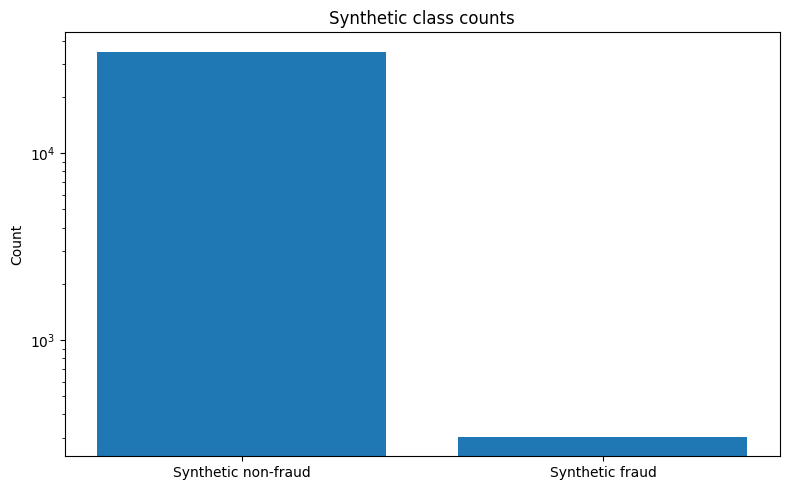

Saved: /kaggle/working/figures/18_synthetic_class_counts.png


In [36]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_SIMULATOR:
    simulated_counts = simulated_df["TX_FRAUD"].value_counts().sort_index()

    plt.figure(figsize=(8, 5))
    plt.bar(
        ["Synthetic non-fraud", "Synthetic fraud"],
        [simulated_counts.get(0, 0), simulated_counts.get(1, 0)]
    )
    plt.yscale("log")
    plt.title("Synthetic class counts")
    plt.ylabel("Count")
    save_show("18_synthetic_class_counts")

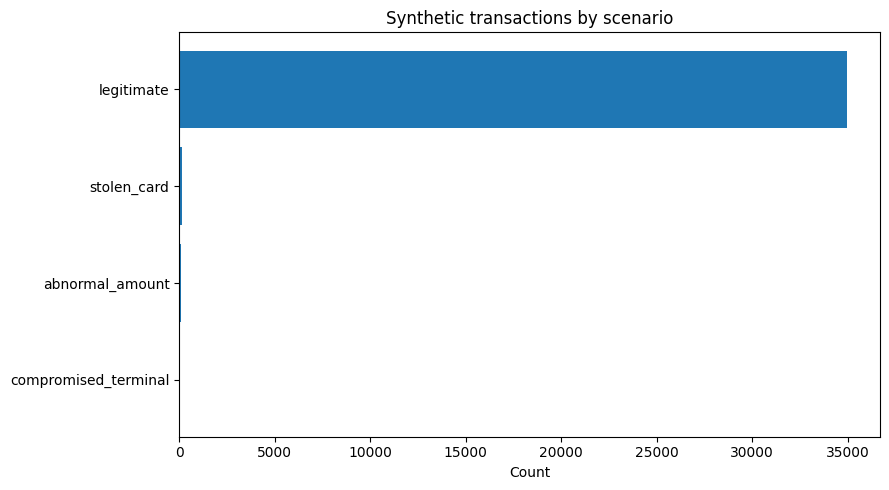

Saved: /kaggle/working/figures/19_synthetic_scenarios.png


In [37]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_SIMULATOR:
    scenario_counts = simulated_df["FRAUD_SCENARIO"].value_counts().sort_values()

    plt.figure(figsize=(9, 5))
    plt.barh(scenario_counts.index, scenario_counts.values)
    plt.title("Synthetic transactions by scenario")
    plt.xlabel("Count")
    save_show("19_synthetic_scenarios")

## 17. Time-based modelling and explainability on synthetic data

In [38]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_SIMULATOR:
    synthetic_features = [
        "TX_AMOUNT", "TX_HOUR", "TX_DAY_OF_WEEK",
        "TX_DURING_NIGHT", "TX_DURING_WEEKEND",
        "CUSTOMER_MEAN_AMOUNT", "CUSTOMER_STD_AMOUNT",
        "DISTANCE_TO_TERMINAL", "AMOUNT_ZSCORE",
        "AMOUNT_TO_MEAN_RATIO", "IS_DISTANT_TERMINAL",
        "TX_TIME_SECONDS"
    ]

    ordered = simulated_df.sort_values("TX_DATETIME").reset_index(drop=True)
    first_cut = int(len(ordered) * 0.70)
    second_cut = int(len(ordered) * 0.85)

    sim_train = ordered.iloc[:first_cut]
    sim_valid = ordered.iloc[first_cut:second_cut]
    sim_test = ordered.iloc[second_cut:]

    X_sim_train = sim_train[synthetic_features]
    y_sim_train = sim_train["TX_FRAUD"]
    X_sim_valid = sim_valid[synthetic_features]
    y_sim_valid = sim_valid["TX_FRAUD"]
    X_sim_test = sim_test[synthetic_features]
    y_sim_test = sim_test["TX_FRAUD"]

    synthetic_weight = (y_sim_train == 0).sum() / max((y_sim_train == 1).sum(), 1)

    synthetic_model = XGBClassifier(
        n_estimators=260 if FAST_MODE else 600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        scale_pos_weight=synthetic_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED
    )

    synthetic_model.fit(X_sim_train, y_sim_train)
    sim_valid_scores = synthetic_model.predict_proba(X_sim_valid)[:, 1]
    sim_threshold, _ = choose_f2_threshold(y_sim_valid, sim_valid_scores)

    sim_test_scores = synthetic_model.predict_proba(X_sim_test)[:, 1]
    sim_metrics = calculate_metrics(y_sim_test, sim_test_scores, sim_threshold)

    display(pd.Series(sim_metrics, name="Synthetic chronological test metrics"))
    print("Synthetic validation-selected threshold:", sim_threshold)
else:
    print("Synthetic modelling disabled.")

threshold                     0.81222
accuracy                      0.99887
balanced_accuracy             0.91429
precision                     1.00000
recall                        0.82857
specificity                   1.00000
f1                            0.90625
f2                            0.85799
roc_auc                       0.96949
average_precision_auprc       0.88011
mcc                           0.90974
brier_score                   0.00389
false_positive_rate           0.00000
false_negative_rate           0.17143
tn                        5,252.00000
fp                            0.00000
fn                            6.00000
tp                           29.00000
Name: Synthetic chronological test metrics, dtype: float64

Synthetic validation-selected threshold: 0.8122155070304871


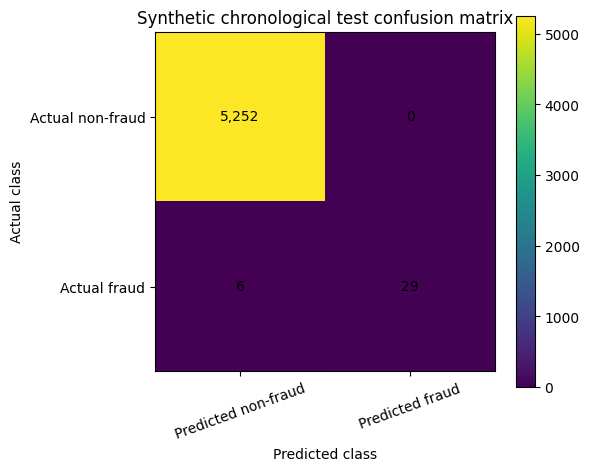

Saved: /kaggle/working/figures/20_synthetic_confusion.png


In [39]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_SIMULATOR:
    plot_confusion(
        y_sim_test,
        sim_test_scores,
        sim_threshold,
        "Synthetic chronological test confusion matrix",
        "20_synthetic_confusion"
    )

,feature,importance_mean,importance_std
8,AMOUNT_ZSCORE,0.36153,0.00653
7,DISTANCE_TO_TERMINAL,0.29386,0.00801
9,AMOUNT_TO_MEAN_RATIO,0.09977,0.01606
0,TX_AMOUNT,0.07305,0.00744
6,CUSTOMER_STD_AMOUNT,0.02335,0.00608
5,CUSTOMER_MEAN_AMOUNT,0.01587,0.00987
10,IS_DISTANT_TERMINAL,0.00436,0.00111
1,TX_HOUR,0.00346,0.00561
2,TX_DAY_OF_WEEK,0.00042,0.00091
3,TX_DURING_NIGHT,0.00000,0.00001


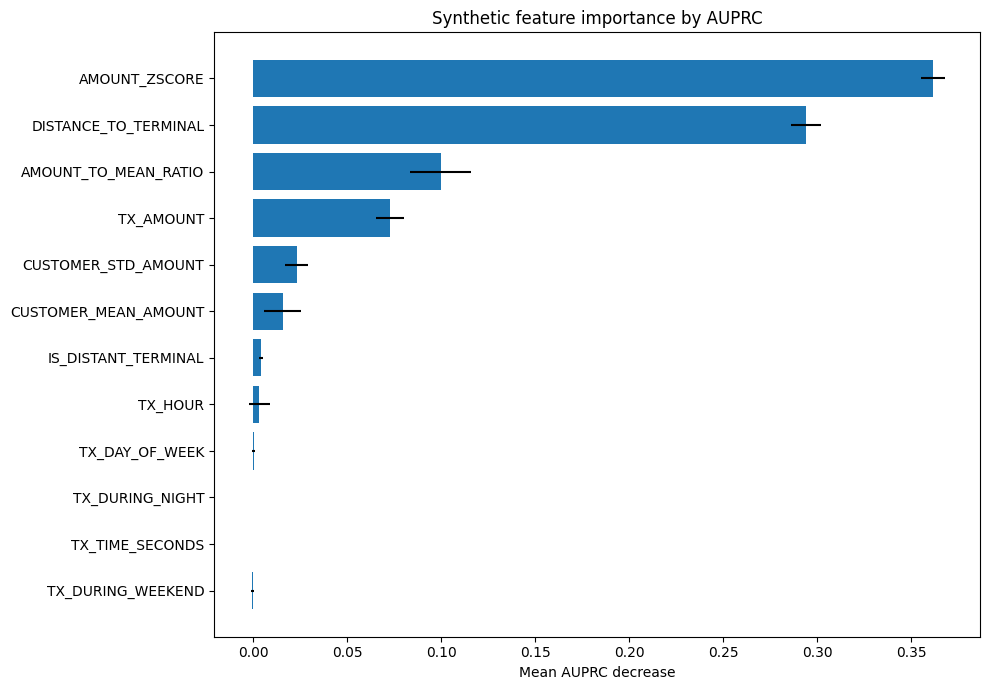

Saved: /kaggle/working/figures/21_synthetic_permutation_importance.png


In [40]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

if RUN_SIMULATOR:
    synthetic_permutation = permutation_importance(
        synthetic_model,
        X_sim_test,
        y_sim_test,
        scoring="average_precision",
        n_repeats=4 if FAST_MODE else 8,
        random_state=SEED,
        n_jobs=-1
    )

    synthetic_importance = pd.DataFrame({
        "feature": synthetic_features,
        "importance_mean": synthetic_permutation.importances_mean,
        "importance_std": synthetic_permutation.importances_std
    }).sort_values("importance_mean", ascending=False)

    display(synthetic_importance)

    synthetic_plot = synthetic_importance.sort_values("importance_mean").tail(12)

    plt.figure(figsize=(10, 7))
    plt.barh(
        synthetic_plot["feature"],
        synthetic_plot["importance_mean"],
        xerr=synthetic_plot["importance_std"]
    )
    plt.title("Synthetic feature importance by AUPRC")
    plt.xlabel("Mean AUPRC decrease")
    save_show("21_synthetic_permutation_importance")

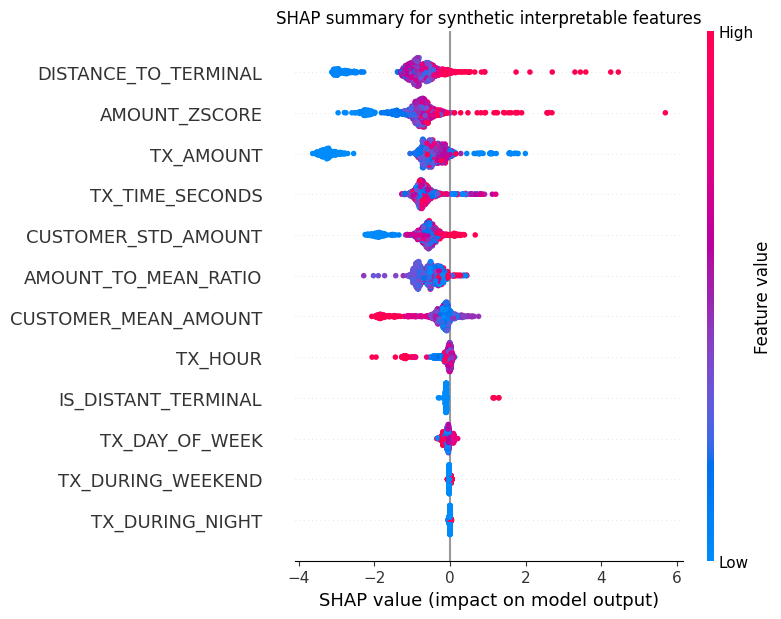

Saved: /kaggle/working/figures/22_synthetic_shap.png


In [41]:
# Import the Python libraries required for data analysis, visualisation,
# machine learning, imbalance handling, evaluation, and file export.

if RUN_SIMULATOR and RUN_SHAP:
    try:
        import shap

        shap_sample = X_sim_test.sample(
            n=min(1000, len(X_sim_test)),
            random_state=SEED
        )
        explainer = shap.TreeExplainer(synthetic_model)
        shap_values = explainer.shap_values(shap_sample)

        shap.summary_plot(
            shap_values,
            shap_sample,
            show=False,
            max_display=12
        )
        plt.title("SHAP summary for synthetic interpretable features")
        save_show("22_synthetic_shap")
    except Exception as error:
        print("SHAP skipped:", repr(error))
else:
    print("SHAP disabled or simulator not run.")

## 18. Chronological robustness test on the real Kaggle data

In [42]:
# Select the strongest validation model using AUPRC, then choose
# a decision threshold on validation data by maximising F2.

time_sorted = df.sort_values("Time").reset_index(drop=True)
time_cut = int(len(time_sorted) * 0.80)

time_train = time_sorted.iloc[:time_cut]
time_test = time_sorted.iloc[time_cut:]

X_time_train = time_train.drop(columns=["Class"])
y_time_train = time_train["Class"]
X_time_test = time_test.drop(columns=["Class"])
y_time_test = time_test["Class"]

chronological_model = clone(models[best_model_name])
chronological_model.fit(X_time_train, y_time_train)
chronological_scores = positive_scores(chronological_model, X_time_test)

chronological_metrics = calculate_metrics(
    y_time_test,
    chronological_scores,
    threshold=best_threshold
)

display(pd.Series(chronological_metrics, name="Chronological holdout metrics"))

threshold                      0.33607
accuracy                       0.99938
balanced_accuracy              0.87823
precision                      0.76712
recall                         0.75676
specificity                    0.99970
f1                             0.76190
f2                             0.75881
roc_auc                        0.98718
average_precision_auprc        0.78448
mcc                            0.76161
brier_score                    0.00052
false_positive_rate            0.00030
false_negative_rate            0.24324
tn                        56,655.00000
fp                            17.00000
fn                            18.00000
tp                            56.00000
Name: Chronological holdout metrics, dtype: float64

## 19. Retrain deployment model and save artifacts

In [43]:
# Summarise the severe class imbalance and the numerical properties
# of the transaction dataset.

deployment_X = pd.concat([X_train, X_valid])
deployment_y = pd.concat([y_train, y_valid])

deployment_model = clone(models[best_model_name])
# Retrain on training plus validation data after evaluation is complete.
deployment_model.fit(deployment_X, deployment_y)

model_path = MODEL_DIR / "fraud_detection_model.joblib"
metadata_path = MODEL_DIR / "model_metadata.json"
metrics_path = MODEL_DIR / "test_metrics.json"
schema_path = MODEL_DIR / "feature_schema.json"
versions_path = MODEL_DIR / "environment_versions.json"

joblib.dump(deployment_model, model_path)

feature_defaults = {
    column: float(deployment_X[column].median())
    for column in deployment_X.columns
}

metadata = {
    "project_title": "Fraud Detection in Financial Transactions Using Ensemble Classification",
    "student": "Aguan Chalamalla",
    "model_name": best_model_name,
    "decision_threshold": float(best_threshold),
    "primary_metric": "Average Precision / AUPRC",
    "feature_names": deployment_X.columns.tolist(),
    "feature_defaults": feature_defaults,
    "training_rows": int(len(deployment_X)),
    "training_fraud_rate": float(deployment_y.mean()),
    "dataset_source": "Kaggle mlg-ulb/creditcardfraud",
    "ethics_notice": (
        "UREC1 academic project using anonymised secondary data. "
        "No human participants and no re-identification. "
        "Not for production banking decisions."
    )
}

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump({key: float(value) for key, value in test_tuned.items()}, file, indent=2)

with open(schema_path, "w", encoding="utf-8") as file:
    json.dump({
        "required_columns": deployment_X.columns.tolist(),
        "target_column": "Class",
        "fraud_label": 1,
        "non_fraud_label": 0
    }, file, indent=2)

package_names = [
    "numpy", "pandas", "scikit-learn",
    "imbalanced-learn", "xgboost", "joblib", "Flask"
]
versions = {"python": platform.python_version()}

for package_name in package_names:
    try:
        versions[package_name] = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        versions[package_name] = "not installed"

with open(versions_path, "w", encoding="utf-8") as file:
    json.dump(versions, file, indent=2)

for path in [model_path, metadata_path, metrics_path, schema_path, versions_path]:
    print("Saved:", path)

Saved: /kaggle/working/model_artifacts/fraud_detection_model.joblib
Saved: /kaggle/working/model_artifacts/model_metadata.json
Saved: /kaggle/working/model_artifacts/test_metrics.json
Saved: /kaggle/working/model_artifacts/feature_schema.json
Saved: /kaggle/working/model_artifacts/environment_versions.json


## 20. Generate the local Flask application

The generated application includes:

- manual single-transaction prediction;
- CSV batch scoring;
- JSON API;
- health endpoint;
- model and ethics information.

Run locally:

```bash
python -m venv .venv

# Windows
.venv\Scripts\activate

# macOS/Linux
source .venv/bin/activate

pip install -r requirements.txt
python app.py
```

Open http://127.0.0.1:5000

In [44]:
# Import the Python libraries required for data analysis, visualisation,
# machine learning, imbalance handling, evaluation, and file export.

from shutil import copy2, make_archive

templates_dir = DEPLOY_DIR / "templates"
templates_dir.mkdir(parents=True, exist_ok=True)

for source_file in [
    model_path, metadata_path, metrics_path, schema_path, versions_path
]:
    copy2(source_file, DEPLOY_DIR / source_file.name)

app_py = """
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
from flask import Flask, jsonify, render_template, request

BASE_DIR = Path(__file__).resolve().parent
app = Flask(__name__)
app.config["MAX_CONTENT_LENGTH"] = 5 * 1024 * 1024

model = joblib.load(BASE_DIR / "fraud_detection_model.joblib")

with open(BASE_DIR / "model_metadata.json", "r", encoding="utf-8") as file:
    metadata = json.load(file)

FEATURES = metadata["feature_names"]
DEFAULTS = metadata["feature_defaults"]
THRESHOLD = float(metadata["decision_threshold"])


def score_frame(frame):
    missing = [feature for feature in FEATURES if feature not in frame.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    numeric = frame[FEATURES].apply(pd.to_numeric, errors="raise")

    if hasattr(model, "predict_proba"):
        return model.predict_proba(numeric)[:, 1]

    if hasattr(model, "decision_function"):
        decision = model.decision_function(numeric)
        return 1 / (1 + np.exp(-decision))

    raise RuntimeError("Model does not provide probability scores.")


@app.get("/")
def home():
    return render_template(
        "index.html",
        features=FEATURES,
        defaults=DEFAULTS,
        metadata=metadata,
        result=None,
        table_html=None,
        error=None
    )


@app.post("/predict")
def predict_single():
    try:
        row = {
            feature: float(request.form.get(feature, DEFAULTS[feature]))
            for feature in FEATURES
        }
        probability = float(score_frame(pd.DataFrame([row]))[0])
        prediction = int(probability >= THRESHOLD)

        result = {
            "probability": probability,
            "prediction": prediction,
            "label": "Potential fraud" if prediction else "Likely non-fraud",
            "threshold": THRESHOLD
        }

        return render_template(
            "index.html",
            features=FEATURES,
            defaults=row,
            metadata=metadata,
            result=result,
            table_html=None,
            error=None
        )
    except Exception as error:
        return render_template(
            "index.html",
            features=FEATURES,
            defaults=DEFAULTS,
            metadata=metadata,
            result=None,
            table_html=None,
            error=str(error)
        ), 400


@app.post("/predict_csv")
def predict_csv():
    try:
        uploaded = request.files.get("file")
        if uploaded is None or uploaded.filename == "":
            raise ValueError("Select a CSV file.")

        frame = pd.read_csv(uploaded)
        if len(frame) > 1000:
            raise ValueError("Maximum 1,000 rows in this academic demo.")

        scores = score_frame(frame)
        output = frame.copy()
        output["fraud_probability"] = scores
        output["fraud_prediction"] = (scores >= THRESHOLD).astype(int)
        output["prediction_label"] = np.where(
            output["fraud_prediction"] == 1,
            "Potential fraud",
            "Likely non-fraud"
        )

        return render_template(
            "index.html",
            features=FEATURES,
            defaults=DEFAULTS,
            metadata=metadata,
            result=None,
            table_html=output.head(100).to_html(
                classes="results-table",
                index=False,
                border=0
            ),
            error=None
        )
    except Exception as error:
        return render_template(
            "index.html",
            features=FEATURES,
            defaults=DEFAULTS,
            metadata=metadata,
            result=None,
            table_html=None,
            error=str(error)
        ), 400


@app.post("/api/predict")
def api_predict():
    try:
        payload = request.get_json(force=True)
        records = [payload] if isinstance(payload, dict) else payload

        if not isinstance(records, list):
            raise ValueError("JSON must be an object or list of objects.")
        if len(records) > 1000:
            raise ValueError("Maximum 1,000 records.")

        scores = score_frame(pd.DataFrame(records))
        predictions = (scores >= THRESHOLD).astype(int)

        result = []
        for score, prediction in zip(scores, predictions):
            result.append({
                "fraud_probability": float(score),
                "fraud_prediction": int(prediction),
                "prediction_label": (
                    "Potential fraud" if prediction else "Likely non-fraud"
                ),
                "threshold": THRESHOLD
            })

        return jsonify(result)
    except Exception as error:
        return jsonify({"error": str(error)}), 400


@app.get("/health")
def health():
    return jsonify({
        "status": "ok",
        "model": metadata["model_name"],
        "threshold": THRESHOLD
    })


if __name__ == "__main__":
    app.run(host="127.0.0.1", port=5000, debug=True)
"""

index_html = """
<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width, initial-scale=1">
<title>Fraud Detection Demo</title>
<style>
body { margin: 0; font-family: Arial, sans-serif; background: #f4f6f8; color: #1f2933; }
.container { width: min(1180px, 94%); margin: 24px auto; }
.card { background: white; border-radius: 14px; padding: 22px; margin-bottom: 20px;
        box-shadow: 0 4px 18px rgba(0,0,0,0.08); }
.grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(180px, 1fr)); gap: 12px; }
label { display: flex; flex-direction: column; gap: 5px; font-weight: 600; }
input { padding: 9px; border: 1px solid #cbd1d8; border-radius: 7px; }
button { margin-top: 16px; padding: 11px 18px; border: 0; border-radius: 8px;
         cursor: pointer; font-weight: 700; }
.notice { border-left: 5px solid #6b7280; padding-left: 14px; }
.result { padding: 14px; border-radius: 9px; background: #eef2f7; }
.error { padding: 14px; border-radius: 9px; background: #ffe9e9; }
.table-wrap { overflow-x: auto; }
.results-table { border-collapse: collapse; width: 100%; font-size: 0.84rem; }
.results-table th, .results-table td { border-bottom: 1px solid #e4e7eb;
                                      padding: 7px; text-align: right; white-space: nowrap; }
code { background: #eef2f7; padding: 2px 5px; border-radius: 4px; }
</style>
</head>
<body>
<div class="container">
<div class="card">
<h1>Credit Card Fraud Detection</h1>
<p><strong>Model:</strong> {{ metadata.model_name }}</p>
<p><strong>Threshold:</strong> {{ "%.6f"|format(metadata.decision_threshold) }}</p>
<p class="notice">{{ metadata.ethics_notice }}</p>
</div>

{% if error %}
<div class="card error"><strong>Error:</strong> {{ error }}</div>
{% endif %}

{% if result %}
<div class="card result">
<strong>{{ result.label }}</strong><br>
Fraud probability: {{ "%.6f"|format(result.probability) }}<br>
Decision threshold: {{ "%.6f"|format(result.threshold) }}
</div>
{% endif %}

<div class="card">
<h2>Single transaction</h2>
<form method="post" action="/predict">
<div class="grid">
{% for feature in features %}
<label>{{ feature }}
<input type="number" step="any" name="{{ feature }}" value="{{ defaults[feature] }}" required>
</label>
{% endfor %}
</div>
<button type="submit">Predict transaction</button>
</form>
</div>

<div class="card">
<h2>CSV batch prediction</h2>
<p>CSV must contain: <code>{{ features|join(", ") }}</code></p>
<form method="post" action="/predict_csv" enctype="multipart/form-data">
<input type="file" name="file" accept=".csv" required>
<button type="submit">Score CSV</button>
</form>
</div>

{% if table_html %}
<div class="card">
<h2>First 100 scored rows</h2>
<div class="table-wrap">{{ table_html|safe }}</div>
</div>
{% endif %}

<div class="card">
<h2>API</h2>
<p>POST JSON to <code>/api/predict</code>. Health endpoint: <code>/health</code>.</p>
</div>
</div>
</body>
</html>
"""

readme_md = f"""
# Fraud Detection Flask Demo

Selected model: {best_model_name}

## Run

python -m venv .venv

Windows:
.venv\\Scripts\\activate

macOS/Linux:
source .venv/bin/activate

pip install -r requirements.txt
python app.py

Open http://127.0.0.1:5000

## Ethics

Academic UREC1 demonstration using anonymised secondary data.
No human participants, no re-identification, and no production banking use.
"""

(DEPLOY_DIR / "app.py").write_text(app_py, encoding="utf-8")
(templates_dir / "index.html").write_text(index_html, encoding="utf-8")
(DEPLOY_DIR / "README.md").write_text(readme_md, encoding="utf-8")

requirements_mapping = {
    "Flask": "Flask",
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "scikit-learn",
    "imbalanced-learn": "imbalanced-learn",
    "xgboost": "xgboost",
    "joblib": "joblib"
}

requirement_lines = []
for display_name, package_name in requirements_mapping.items():
    try:
        version = importlib.metadata.version(package_name)
        requirement_lines.append(f"{display_name}=={version}")
    except importlib.metadata.PackageNotFoundError:
        requirement_lines.append(display_name)

(DEPLOY_DIR / "requirements.txt").write_text(
    "\n".join(requirement_lines) + "\n",
    encoding="utf-8"
)

zip_path = Path(make_archive(
    str(OUTPUT_DIR / "fraud_flask_app"),
    "zip",
    root_dir=DEPLOY_DIR
))

print("Flask folder:", DEPLOY_DIR)
print("Flask ZIP:", zip_path)
for file_path in sorted(DEPLOY_DIR.rglob("*")):
    if file_path.is_file():
        print("-", file_path.relative_to(DEPLOY_DIR))

Flask folder: /kaggle/working/fraud_flask_app
Flask ZIP: /kaggle/working/fraud_flask_app.zip
- README.md
- app.py
- environment_versions.json
- feature_schema.json
- fraud_detection_model.joblib
- model_metadata.json
- requirements.txt
- templates/index.html
- test_metrics.json


## 21. Create a sample CSV for the Flask application

In [45]:
# Create stratified training, validation, and untouched test sets.
# Splitting first prevents information leakage into final evaluation.

sample_csv = OUTPUT_DIR / "sample_transactions_for_flask.csv"
X_test.head(20).to_csv(sample_csv, index=False)

print("Saved:", sample_csv)
display(X_test.head())

Saved: /kaggle/working/sample_transactions_for_flask.csv


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
86249,"61,290.00000",1.22882,-0.06341,0.27415,0.64747,-0.04813,0.37207,-0.22423,0.07994,0.64076,-0.27305,-1.25273,0.46508,0.40050,-0.29284,-0.10177,-0.39984,0.03434,-0.78355,0.14134,-0.09657,-0.12955,-0.08378,-0.15166,-0.70037,0.59855,0.49141,0.00299,0.00178,11.50000
250634,"155,394.00000",-0.20315,1.17668,-0.75959,-0.51847,0.62965,-0.72167,0.63889,0.24338,-0.15749,-0.50660,-1.39484,-0.09247,0.02163,0.73080,0.49634,-0.19959,-0.43439,0.34866,0.16252,-0.09843,0.38463,1.20675,-0.08275,0.50839,-0.71091,-0.23451,0.37964,0.26135,1.94000
20163,"30,881.00000",-1.67284,1.40130,1.50394,2.17549,0.69979,1.06214,1.11436,-0.53582,-0.25298,3.07122,0.76857,0.20207,1.34918,-0.95057,0.92205,0.36700,-1.21549,0.59861,1.42597,0.82847,-0.52595,-0.40874,-0.28008,-0.84647,-0.15546,-0.06238,0.00778,0.11390,91.28000
68688,"53,203.00000",0.81938,-1.12491,0.51502,0.51394,-1.00905,0.48848,-0.58067,0.18769,-0.99914,0.87197,0.90660,0.38640,0.10152,0.27554,0.70347,-1.00496,-0.42590,1.77401,-1.39961,-0.11014,-0.05721,-0.16806,-0.19873,-0.33741,0.23854,-0.28945,0.03821,0.05841,228.00000
191151,"129,429.00000",2.00970,0.10564,-1.75276,0.58831,0.37480,-0.63788,0.00926,-0.12949,0.49262,-0.52704,0.98511,1.03650,0.41764,-1.64189,-1.12347,0.31682,0.89198,0.61057,0.21580,-0.13548,0.00897,0.35739,-0.01347,-0.44692,0.11152,0.64294,-0.03700,-0.04340,1.41000


## 22. Save comparison tables and project summary

In [46]:
# Validate the dataset structure and data quality before analysis.
# This checks columns, missing values, class labels, and duplicate records.

validation_results.to_csv(
    OUTPUT_DIR / "validation_model_comparison.csv",
    index=True
)
test_comparison.to_csv(
    OUTPUT_DIR / "final_test_metrics.csv",
    index=True
)
importance_df.to_csv(
    OUTPUT_DIR / "real_data_permutation_importance.csv",
    index=False
)

project_summary = f"""
# Fraud Detection Project Summary

## Ethics
- UREC1 project with no human participants.
- Main data is an anonymised secondary dataset.
- Optional simulator data is non-real and synthetic.
- No re-identification is attempted.
- Flask application is an academic demonstration only.

## Dataset
- Kaggle source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Rows after optional duplicate removal: {len(df):,}
- Fraud rate: {df['Class'].mean():.6%}

## Selected model
- Model: {best_model_name}
- Validation-selected threshold: {best_threshold:.8f}
- Primary model-selection metric: Average Precision / AUPRC

## Untouched test results
- AUPRC: {test_tuned['average_precision_auprc']:.6f}
- ROC-AUC: {test_tuned['roc_auc']:.6f}
- Precision: {test_tuned['precision']:.6f}
- Recall: {test_tuned['recall']:.6f}
- F1: {test_tuned['f1']:.6f}
- F2: {test_tuned['f2']:.6f}
- MCC: {test_tuned['mcc']:.6f}
- False positives: {test_tuned['fp']}
- False negatives: {test_tuned['fn']}

## Limitations
- The real dataset covers only two days in September 2013.
- V1–V28 are anonymous PCA components.
- Fraud patterns can change over time.
- Simulator results do not prove real-world deployment performance.
- Threshold choice depends on business costs and investigation capacity.
"""

summary_path = OUTPUT_DIR / "PROJECT_SUMMARY.md"
summary_path.write_text(project_summary, encoding="utf-8")

print(project_summary)
print("Saved:", summary_path)


# Fraud Detection Project Summary

## Ethics
- UREC1 project with no human participants.
- Main data is an anonymised secondary dataset.
- Optional simulator data is non-real and synthetic.
- No re-identification is attempted.
- Flask application is an academic demonstration only.

## Dataset
- Kaggle source: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- Rows after optional duplicate removal: 283,726
- Fraud rate: 0.166710%

## Selected model
- Model: XGBoost weighted
- Validation-selected threshold: 0.33606732
- Primary model-selection metric: Average Precision / AUPRC

## Untouched test results
- AUPRC: 0.819534
- ROC-AUC: 0.973421
- Precision: 0.791667
- Recall: 0.800000
- F1: 0.795812
- F2: 0.798319
- MCC: 0.795478
- False positives: 20
- False negatives: 19

## Limitations
- The real dataset covers only two days in September 2013.
- V1–V28 are anonymous PCA components.
- Fraud patterns can change over time.
- Simulator results do not prove real-world deployment perfor

## 23. Output manifest

In [47]:
# Project configuration: these switches control reproducibility,
# runtime, optional experiments, and output locations.

manifest = []

for file_path in sorted(OUTPUT_DIR.rglob("*")):
    if file_path.is_file():
        manifest.append({
            "file": str(file_path.relative_to(OUTPUT_DIR)),
            "size_kb": round(file_path.stat().st_size / 1024, 2)
        })

manifest_df = pd.DataFrame(manifest)
display(manifest_df)
manifest_df.to_csv(OUTPUT_DIR / "output_manifest.csv", index=False)

print("Important downloads:")
print("-", OUTPUT_DIR / "fraud_flask_app.zip")
print("-", MODEL_DIR / "fraud_detection_model.joblib")
print("-", OUTPUT_DIR / "validation_model_comparison.csv")
print("-", OUTPUT_DIR / "final_test_metrics.csv")
print("-", OUTPUT_DIR / "PROJECT_SUMMARY.md")
if RUN_SIMULATOR:
    print("-", OUTPUT_DIR / "simulated_transactions.csv")

,file,size_kb
0,.virtual_documents/__notebook_source__.ipynb,57.28000
1,PROJECT_SUMMARY.md,1.06000
2,figures/01_class_counts.png,25.25000
3,figures/02_class_percentages.png,30.21000
4,figures/03_amount_distribution.png,47.69000
5,figures/04_amount_boxplot.png,30.12000
6,figures/05_hourly_fraud_rate.png,67.91000
7,figures/06_amount_decile_fraud_rate.png,53.28000
8,figures/07_balanced_correlations.png,46.22000
9,figures/08_correlation_matrix.png,52.31000


Important downloads:
- /kaggle/working/fraud_flask_app.zip
- /kaggle/working/model_artifacts/fraud_detection_model.joblib
- /kaggle/working/validation_model_comparison.csv
- /kaggle/working/final_test_metrics.csv
- /kaggle/working/PROJECT_SUMMARY.md
- /kaggle/working/simulated_transactions.csv


# Interpretation guidance for the dissertation

The final report should distinguish:

1. **Ranking quality:** AUPRC and ROC-AUC.
2. **Operating performance:** Precision, Recall, F2, false positives, and false negatives at the selected threshold.
3. **Calibration:** whether estimated probabilities correspond to observed fraud rates.
4. **Explainability:** influential PCA features versus interpretable simulator features.
5. **Generalisation:** validation, cross-validation, and chronological results.
6. **Ethical compliance:** anonymised secondary data and non-real simulated data only.

Do not claim that performance on this historical two-day dataset makes the system ready for real banking deployment. Production use would require current data, concept-drift monitoring, security testing, human review procedures, model governance, and operational validation.